# Turbulence synthesis: quantile ψ vs generalized-Gaussian ψ potential

This notebook runs the same 1D turbulence synthesis experiment twice:

1. **Baseline quantile model**
   ```python
   ['Scattering_Second_Order', 'Scattering_Fourth_Order_Real',
    'Scalar_psi_quantile_confine', 'Scalar_morlet_quantile_confine']
   ```

2. **Generalized-Gaussian ψ model**
   ```python
   ['Scattering_Second_Order', 'Scattering_Fourth_Order_Real',
    'Scalar_psi_generalized_gaussian', 'Scalar_morlet_generalized_gaussian']
   ```

The two runs are saved under different configuration names. The generalized-Gaussian run appends
`_generalized_gauss` to the saved sample name.


In [15]:
import torch
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats, ndimage
import math 

import sys
from pathlib import Path

root = Path().resolve()

sys.path.insert(0, str(root / '../codes'))
from sde_routines_condi import *
from sde_routines import *
from potentials_builder import *
from filters_bank import * 
from utils import *
from utils_entropy import *
from check_moments import *
from potentials import *
from filters import *
from mala import *
from ortho_wavelet import *

sys.path.insert(0, str(root / '../data'))
from data_loader import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print(root)

device: cuda
/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence


## Data preprocessing

In [17]:
# Orthogonal wavelet
W = DefineWavelet('Db', m=3, device=device)

Data = load_turbulence_1d()
print(Data.shape) 

n1 = 1024
Data = split_periodize_reshape(Data, n1)

#B, C, L = Data.shape
print(Data.shape) 

# Same preprocessing as in the original notebook.
for j in range(2):
    Data = W.decompose(Data)[1]

x1 = normalize(Data[:10000]).to(device) # choose here if you want less data 
print('Data shape after preprocessing:', Data.shape)
print('x1 shape:', x1.shape) 

n1, channels, M = x1.shape
print(f'(B, C, T) = ({n1}, {channels}, {M}).')
J = 7 
Q = 3

torch.Size([10000, 1, 1800])
torch.Size([10000, 1, 1024])
Data shape after preprocessing: torch.Size([10000, 1, 256])
x1 shape: torch.Size([10000, 1, 256])
(B, C, T) = (10000, 1, 256).


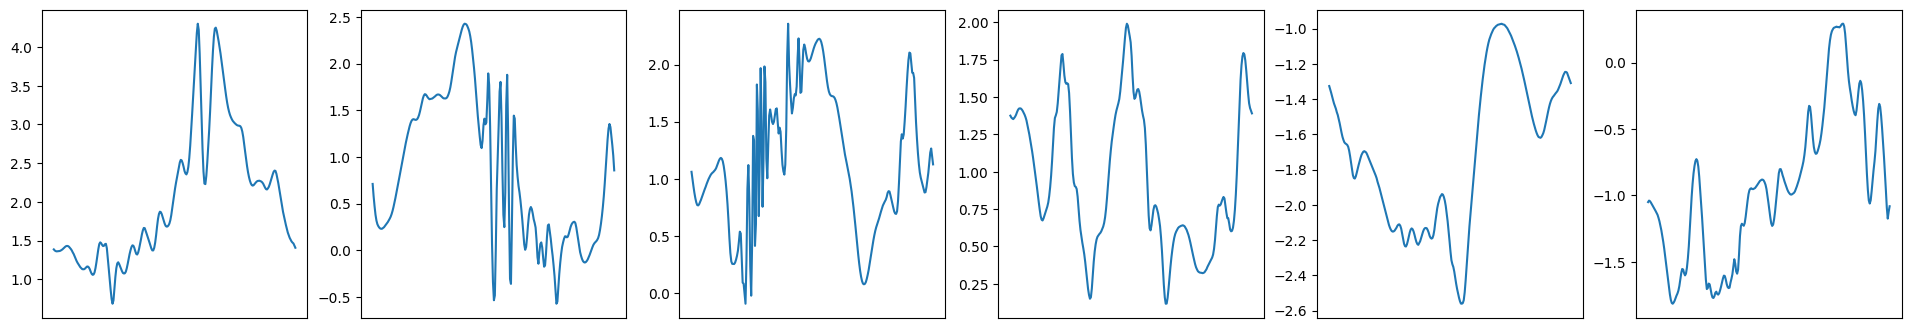

In [18]:
%matplotlib inline 
plot_time_series_row(x1, 6)


## Investigating wavelet coefficients histograms: lin/log scale etc 

# Fitting wavelet transforms with Generalized Gaussian windows model: Q=1  

In [47]:
def plot_kregion_fit_with_windows(x, model, label="", channels=None, ncols=4,
                                   n_grid=800, figsize_per=(4.6, 3.6)):
    """
    Paper-figure helper for Scalar_GGD_KRegion.

    For each channel, draws:
      - the empirical histogram of wavelet coefficients (log density)
      - the fitted per-region truncated-GGD densities (bulk ... tail),
        each colored by region and labeled with alpha / mixture weight
      - on a twin axis: the smooth partition-of-unity windows w_k(z)
        that implement the bulk/tail blending, with cut locations and
        their +/-2*s transition zones shaded

    Does not refit -- uses model.alpha/scale/cuts/sw/pi/active as fitted.
    """
    model._check_fitted()
    filters = model.filters.to(x.device)
    wt = torch.fft.ifft(torch.fft.fft(x) * filters).real

    A = model.alpha.cpu().numpy();  S = model.scale.cpu().numpy()
    C = model.cuts.cpu().numpy();   SW = model.sw.cpu().numpy()
    P = model.pi.cpu().numpy();     ACT = model.active.cpu().numpy()
    Keff = model.Keff.cpu().numpy()
    J, K = A.shape

    if channels is None:
        channels = list(range(J))
    ncols = min(ncols, len(channels))
    nrows = math.ceil(len(channels) / ncols)
    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(figsize_per[0]*ncols, figsize_per[1]*nrows))
    axes = np.atleast_1d(axes).flatten()

    region_colors = plt.cm.plasma(np.linspace(0.12, 0.85, K))
    region_names = (["bulk"] + [f"mid{k}" for k in range(1, K - 1)]
                     + (["tail"] if K > 1 else []))

    for idx, j in enumerate(channels):
        ax = axes[idx]
        h = wt[:, j, :].detach().cpu().flatten().numpy()
        h = h[np.isfinite(h)]
        ah = np.abs(h)
        xmax = float(ah.max()) * 1.02
        edges = [0.0] + list(C[j]) + [xmax]

        ax.hist(h, bins=120, density=True, log=True, alpha=0.35,
                 color="0.6", zorder=1, label="data")

        # --- fitted densities, per region ---
        for k in range(K):
            if P[j, k] < 1e-4:
                continue
            lo, hi = edges[k], edges[k + 1]
            hi_fit = np.inf if k == K - 1 else hi
            xp = np.linspace(max(lo, 1e-6), hi, n_grid)
            lp = model._logpdf_trunc(xp, A[j, k], S[j, k], lo, hi_fit, P[j, k])
            xx = np.concatenate([-xp[::-1], xp])
            yy = np.exp(np.concatenate([lp[::-1], lp]))
            name = region_names[k] if k < len(region_names) else f"r{k}"
            star = "*" if ACT[j, k] else ""
            ax.plot(xx, yy, lw=2.2, color=region_colors[k], zorder=3,
                     label=f"{name}{star} α={A[j,k]:.2f} π={P[j,k]:.1%}")

        # --- windowing functions w_k(z), on a twin axis ---
        axt = ax.twinx()
        zg = np.linspace(-xmax, xmax, 1000)
        az = np.abs(zg)

        if K == 1:
            ws = [np.ones_like(az)]
        else:
            g = [1.0 / (1.0 + np.exp(-(C[j, m] - az) / SW[j, m]))
                 for m in range(K - 1)]  # sigmoid(-(|z|-c_m)/s_m), matches model internals
            ws = [g[0]]
            for m in range(1, K - 1):
                ws.append(g[m] - g[m - 1])
            ws.append(1.0 - g[K - 2])

        for k in range(K):
            name = region_names[k] if k < len(region_names) else f"r{k}"
            axt.plot(zg, ws[k], lw=1.4, ls="--", color=region_colors[k],
                      alpha=0.9, zorder=2, label=f"w_{name}")

        for c_m, s_m in zip(C[j], SW[j]):
            for sign in (-1, 1):
                axt.axvline(sign * c_m, color="k", ls=":", lw=0.8, alpha=0.5, zorder=2)
                axt.axvspan(sign * c_m - 2 * s_m, sign * c_m + 2 * s_m,
                             color="gray", alpha=0.12, zorder=0)

        axt.set_ylim(-0.05, 1.05)
        axt.set_ylabel("window weight")

        ax.set_xlabel("coefficient value")
        ax.set_ylabel("log density")
        ax.set_title(f"{label}  ch={j}  (Keff={int(Keff[j])})", fontsize=10)
        ax.legend(fontsize=6.5, loc="upper left", framealpha=0.85)
        if idx == 0:
            axt.legend(fontsize=6.5, loc="upper right", framealpha=0.85)

    for k in range(len(channels), len(axes)):
        axes[k].axis("off")

    plt.suptitle(f"Bulk/tail windowing and per-region fit — {label}", fontsize=13)
    plt.tight_layout()
    plt.show()

def plot_kregion_fit_paper(x, model, channel, label="", n_grid=800,
                            figsize=(9, 8), fontsize=15):
    """
    Single-channel, publication-ready figure for Scalar_GGD_KRegion.

    Two stacked panels sharing the x-axis (coefficient value):
      - top:    the smooth partition-of-unity windows w_k(z) that blend
                the K regions (bulk -> mid -> ... -> tail)
      - bottom: empirical histogram of the wavelet coefficients (log
                density) with the fitted truncated-GGD density overlaid
                per region, colored to match the window it corresponds to

    Does not refit -- uses model.alpha/scale/cuts/sw/pi/active as already
    fitted by model.fit_reference(...).
    """
    model._check_fitted()
    j = channel

    filters = model.filters.to(x.device)
    wt = torch.fft.ifft(torch.fft.fft(x) * filters).real

    A = model.alpha.cpu().numpy();  S = model.scale.cpu().numpy()
    C = model.cuts.cpu().numpy();   SW = model.sw.cpu().numpy()
    P = model.pi.cpu().numpy();     ACT = model.active.cpu().numpy()
    Keff = model.Keff.cpu().numpy()
    K = A.shape[1]

    h = wt[:, j, :].detach().cpu().flatten().numpy()
    h = h[np.isfinite(h)]
    ah = np.abs(h)
    xmax = float(ah.max()) * 1.02
    edges = [0.0] + list(C[j]) + [xmax]

    region_colors = plt.cm.plasma(np.linspace(0.12, 0.85, K))
    region_names = (["bulk"] + [f"mid_{{{k}}}" for k in range(1, K - 1)]
                     + (["tail"] if K > 1 else []))

    fig, (ax_w, ax_d) = plt.subplots(
        2, 1, figsize=figsize, sharex=True,
        gridspec_kw=dict(height_ratios=[1, 2.4], hspace=0.06))

    # ------------------------------------------------------------------
    # top panel: windows w_k(z)
    # ------------------------------------------------------------------
    zg = np.linspace(-xmax, xmax, 1000)
    az = np.abs(zg)
    if K == 1:
        ws = [np.ones_like(az)]
    else:
        g = [1.0 / (1.0 + np.exp(-(C[j, m] - az) / SW[j, m])) for m in range(K - 1)]
        ws = [g[0]]
        for m in range(1, K - 1):
            ws.append(g[m] - g[m - 1])
        ws.append(1.0 - g[K - 2])

    for k in range(K):
        name = region_names[k] if k < len(region_names) else f"r_{{{k}}}"
        ax_w.plot(zg, ws[k], lw=2.6, color=region_colors[k],
                  label=rf"$w_{{{name}}}$")

    for c_m, s_m in zip(C[j], SW[j]):
        for sign in (-1, 1):
            ax_w.axvline(sign * c_m, color="k", ls=":", lw=1.0, alpha=0.6)
            ax_d.axvline(sign * c_m, color="k", ls=":", lw=1.0, alpha=0.5)
            ax_w.axvspan(sign * c_m - 2 * s_m, sign * c_m + 2 * s_m,
                         color="gray", alpha=0.12)
            ax_d.axvspan(sign * c_m - 2 * s_m, sign * c_m + 2 * s_m,
                         color="gray", alpha=0.12)

    ax_w.set_ylim(-0.05, 1.08)
    ax_w.set_ylabel("window\nweight", fontsize=fontsize)
    ax_w.legend(fontsize=fontsize - 3, ncol=K, loc="upper center",
                bbox_to_anchor=(0.5, 1.35), frameon=False)
    ax_w.tick_params(labelsize=fontsize - 2)

    # ------------------------------------------------------------------
    # bottom panel: data histogram + fitted densities
    # ------------------------------------------------------------------
    ax_d.hist(h, bins=120, density=True, log=True, alpha=0.35,
              color="0.55", label="data", zorder=1)

    for k in range(K):
        if P[j, k] < 1e-4:
            continue
        lo, hi = edges[k], edges[k + 1]
        hi_fit = np.inf if k == K - 1 else hi
        xp = np.linspace(max(lo, 1e-6), hi, n_grid)
        lp = model._logpdf_trunc(xp, A[j, k], S[j, k], lo, hi_fit, P[j, k])
        xx = np.concatenate([-xp[::-1], xp])
        yy = np.exp(np.concatenate([lp[::-1], lp]))
        name = region_names[k] if k < len(region_names) else f"r_{{{k}}}"
        star = r"$^{*}$" if ACT[j, k] else ""
        ax_d.plot(xx, yy, lw=3, color=region_colors[k], zorder=3,
                  label=rf"${name}${star}: $\alpha$={A[j,k]:.2f}, $\pi$={P[j,k]:.1%}")

    ax_d.set_xlabel("coefficient value $x$", fontsize=fontsize)
    ax_d.set_ylabel("log density", fontsize=fontsize)
    ax_d.legend(fontsize=fontsize - 3, loc="upper right", framealpha=0.9)
    ax_d.tick_params(labelsize=fontsize - 2)

    fig.suptitle(f"{label}  —  channel {j}  ($K_{{eff}}$={int(Keff[j])})",
                 fontsize=fontsize + 2, y=1.0)
    y_thresh = 1e-4
    ax_d.set_ylim(bottom=y_thresh)
    plt.tight_layout()
    plt.savefig("fitting_Q3_marginal.png") 

    plt.show()
    return fig

In [ ]:
import numpy as np

# ----------------------------------------------------------------------
# 1. Eff-N-driven threshold selection (replaces fixed bulk_quantile logic)
# ----------------------------------------------------------------------
def _select_threshold_by_eff_n(ah, target_eff_n=300.0,
                                q_grid=None, min_q=0.80, max_q=0.999):
    """
    Pick the bulk/tail border c (and the quantile q it corresponds to) so
    that the tail window's EFFECTIVE sample size hits `target_eff_n`,
    instead of fixing the percentile a priori. This is what makes the
    method scale-adaptive: peaked channels (scale 0) will push c to a
    much higher percentile than smooth/Gaussian channels (scale 6),
    automatically, because that's what it takes to get enough effective
    tail mass in each case.

    Scans q from low to high; returns the FIRST q (lowest, i.e. widest
    tail) whose eff_N drops to <= target. If no q in the grid achieves
    eff_N <= target (e.g. very heavy-tailed data with huge eff_N even at
    high q), falls back to max_q.
    """
    ah = np.asarray(ah, dtype=float)
    if q_grid is None:
        q_grid = np.linspace(min_q, max_q, 120)
    candidates = np.quantile(ah, q_grid)

    for q, c_try in zip(q_grid, candidates):
        s_try = max(0.05 * c_try, 1e-6)  # provisional width just for eff_N probe
        w_tail = 1.0 / (1.0 + np.exp(-(ah - c_try) / s_try))
        eff_n = (w_tail.sum() ** 2) / max((w_tail ** 2).sum(), 1e-12)
        if eff_n <= target_eff_n:
            return float(c_try), float(q), float(eff_n)

    # fell through: even the most permissive q didn't bring eff_N down
    # to target (rare) -> use the most conservative (highest q) candidate
    c_fallback = float(candidates[-1])
    s_try = max(0.05 * c_fallback, 1e-6)
    w_tail = 1.0 / (1.0 + np.exp(-(ah - c_fallback) / s_try))
    eff_n = (w_tail.sum() ** 2) / max((w_tail ** 2).sum(), 1e-12)
    return c_fallback, float(q_grid[-1]), float(eff_n)


# ----------------------------------------------------------------------
# 2. Hill-estimator tail-index init (replaces blind b0=1.0/t0=4.0 start)
# ----------------------------------------------------------------------
def _hill_tail_init(h, c, t_bounds=(0.5, 50.0)):
    """
    Rough power-law tail-index estimate via the Hill estimator, used only
    as an initial guess for the (b, t, a, x0) MLE -- not the final fit.
    Returns a t0 clipped into t_bounds, or None if too few exceedances.
    """
    ah = np.abs(np.asarray(h, dtype=float))
    excess = ah[ah > c]
    if excess.size < 10:
        return None
    log_ratio = np.log(excess / c)
    xi_hat = float(log_ratio.mean())
    if not np.isfinite(xi_hat) or xi_hat <= 1e-6:
        return None
    t0 = 1.0 / xi_hat
    return float(np.clip(t0, t_bounds[0], t_bounds[1]))


# ----------------------------------------------------------------------
# 3. Patched fit_reference: same structure as the original, but threshold
#    selection is eff-N-driven and the tail fit gets a Hill-based t0 init.
# ----------------------------------------------------------------------
def fit_reference_v3(self, x, lam=1.0, lr_thresh=2.0,
                      bulk_quantile=None, trans_quantiles=None,
                      tail_hard_margin=1.0):
    """
    Same as fit_reference, except the TAIL fit uses a hard-cutoff subset
    (|z| > c + tail_hard_margin*s) with uniform weight 1, instead of the
    smooth sigmoid weights. Rationale: the smooth window's likelihood is
    dominated by the dense near-boundary region (lots of raw samples
    there even at low w_tail), which biases the fit toward the shallow
    local slope rather than the true far-tail decay. The smooth window
    (self.c, self.s) is UNCHANGED and still used for forward()/grad()'s
    differentiable mixing -- only the parameter-estimation weighting
    changes.
    """
    if bulk_quantile is None:
        bulk_quantile = self.bulk_quantile
    if trans_quantiles is None:
        trans_quantiles = self.trans_quantiles

    filters = self.filters.to(x.device)
    z = torch.fft.ifft(filters * torch.fft.fft(x)).real.detach().cpu().numpy()

    bb_b, tt_b, aa_b, xx_b = [], [], [], []
    bb_t, tt_t, aa_t, xx_t = [], [], [], []
    cc, ss, cosines = [], [], []

    for j in range(z.shape[1]):
        h = z[:, j, :].reshape(-1)
        h = h[np.isfinite(h)]
        ah = np.abs(h)

        if h.size < 10:
            b_, t_, x0_ = 1.0, 4.0, 1.0
            c_ = float(np.median(ah)) if ah.size else 1.0
            s_ = max(0.1 * c_, self.eps_scale)
            bb_b += [b_]; tt_b += [t_]; aa_b += [0.0]; xx_b += [x0_]
            bb_t += [b_]; tt_t += [max(t_, 1.0)]; aa_t += [0.0]; xx_t += [x0_]
            cc += [c_]; ss += [s_]; cosines += [0.0]
            continue

        c_ = float(np.quantile(ah, bulk_quantile))
        q_lo, q_hi = trans_quantiles
        band = float(np.quantile(ah, q_hi) - np.quantile(ah, q_lo))
        s_ = band / 4.0
        s_ = max(s_, 0.05 * (c_ + self.eps_scale), self.eps_scale)

        # smooth window: kept ONLY for diagnostics / downstream consistency
        w_tail_smooth = 1.0 / (1.0 + np.exp(-(ah - c_) / s_))
        w_bulk = 1.0 - w_tail_smooth

        # --- NEW: hard cutoff for the TAIL FIT ONLY ---
        hard_cut = c_ + tail_hard_margin * s_
        tail_mask = ah > hard_cut
        n_hard_tail = int(tail_mask.sum())
        print(f"[coshGT2][ch {j}] hard-tail cutoff={hard_cut:.4f}  "
              f"N_hard_tail={n_hard_tail}")

        if n_hard_tail < self.min_eff_samples:
            print(f"[coshGT2][ch {j}] N_hard_tail={n_hard_tail} < "
                  f"{self.min_eff_samples:.0f}: widen the hard cutoff "
                  f"(lower bulk_quantile) or accept a noisier tail fit.")

        try:
            b_bk, t_bk, a_bk, x0_bk = self._fit_channel(
                h, weights=w_bulk, a0=0.05, lam=lam, lr_thresh=lr_thresh,
                b_bounds=self.b_bounds, t_bounds=self.t_bounds,
                a_max=self.a_max, eps_scale=self.eps_scale)
        except Exception as e:
            print(f"[coshGT2][ch {j}] bulk fit failed ({e}) -> fallback")
            b_bk, t_bk, a_bk, x0_bk = 1.0, 6.0, 0.0, float(np.std(h) + self.eps_scale)

        try:
            if n_hard_tail >= 10:
                h_tail_subset = h[tail_mask]
                w_hard = np.ones_like(h_tail_subset)
                t0_hill = _hill_tail_init(h, c_, t_bounds=self.t_bounds)
                t0_tail = t0_hill if t0_hill is not None else 4.0
                b_tl, t_tl, a_tl, x0_tl = self._fit_channel(
                    h_tail_subset, weights=w_hard, b0=1.0, t0=t0_tail, a0=0.10,
                    lam=lam, lr_thresh=lr_thresh,
                    b_bounds=self.b_bounds, t_bounds=self.t_bounds,
                    a_max=self.a_max, eps_scale=self.eps_scale)
            else:
                raise RuntimeError(f"only {n_hard_tail} hard-tail samples")
        except Exception as e:
            print(f"[coshGT2][ch {j}] tail fit failed ({e}) -> fallback")
            b_tl, t_tl, a_tl, x0_tl = 1.0, 3.0, 0.0, float(np.std(h) + self.eps_scale)

        b_bk = float(np.clip(b_bk, *self.b_bounds)); t_bk = float(np.clip(t_bk, *self.t_bounds))
        a_bk = float(np.clip(a_bk, 0.0, self.a_max)); x0_bk = float(max(x0_bk, self.eps_scale))
        b_tl = float(np.clip(b_tl, *self.b_bounds)); t_tl = float(np.clip(t_tl, *self.t_bounds))
        a_tl = float(np.clip(a_tl, 0.0, self.a_max)); x0_tl = float(max(x0_tl, self.eps_scale))

        cos_bt = self._potential_cosine(
            c_, s_, (b_bk, t_bk, a_bk, x0_bk), (b_tl, t_tl, a_tl, x0_tl))

        print(f"[coshGT2][ch {j}] c={c_:.4f} s={s_:.4f} | "
              f"bulk(b={b_bk:.3f},t={t_bk:.3f},a={a_bk:.4f},x0={x0_bk:.4f}) | "
              f"tail(b={b_tl:.3f},t={t_tl:.3f},a={a_tl:.4f},x0={x0_tl:.4f}) | "
              f"cos={cos_bt:.3f}")

        bb_b += [b_bk]; tt_b += [t_bk]; aa_b += [a_bk]; xx_b += [x0_bk]
        bb_t += [b_tl]; tt_t += [t_tl]; aa_t += [a_tl]; xx_t += [x0_tl]
        cc += [c_]; ss += [s_]; cosines += [cos_bt]

    dtype = x.dtype if x.is_floating_point() else torch.float32
    dev = x.device
    mk = lambda L: torch.tensor(L, dtype=dtype, device=dev)
    self.b_bulk, self.t_bulk, self.a_bulk, self.x0_bulk = mk(bb_b), mk(tt_b), mk(aa_b), mk(xx_b)
    self.b_tail, self.t_tail, self.a_tail, self.x0_tail = mk(bb_t), mk(tt_t), mk(aa_t), mk(xx_t)
    self.c, self.s = mk(cc), mk(ss)
    self.cos_bt = mk(cosines)

Scalar_coshgt.fit_reference_v3 = fit_reference_v3
Scalar_coshgt._hill_tail_init = staticmethod(_hill_tail_init)

"""
#####################################################
# FITTING FUNCTION 
#####################################################
def plot_coshgt_wavelet_fit(x: torch.Tensor,
                             model: "Scalar_coshgt",
                             label: str = "Wavelet",
                             n_grid: int = 1000,
                             tail_pad_s: float = 2.0,
                             fit_if_needed: bool = True) -> None:
    if fit_if_needed and not model.is_fitted:
        model.fit_reference(x)
    model._check_fitted()

    filters = model.filters.to(x.device)
    wt = torch.fft.ifft(torch.fft.fft(x) * filters).real  # (B, J, T)
    n_wavelets = filters.shape[1]

    c_all = model.c.cpu().numpy();  s_all = model.s.cpu().numpy()
    b_bk = model.b_bulk.cpu().numpy(); t_bk = model.t_bulk.cpu().numpy()
    a_bk = model.a_bulk.cpu().numpy(); x0_bk = model.x0_bulk.cpu().numpy()
    b_tl = model.b_tail.cpu().numpy(); t_tl = model.t_tail.cpu().numpy()
    a_tl = model.a_tail.cpu().numpy(); x0_tl = model.x0_tail.cpu().numpy()

    for j in range(n_wavelets):
        h = wt[:, j, :].detach().cpu().flatten().numpy()
        h = h[np.isfinite(h)]
        if h.size == 0:
            continue
        ah = np.abs(h)

        c_j, s_j = float(c_all[j]), float(s_all[j])
        bulk_edge = c_j + tail_pad_s * s_j
        tail_edge = max(c_j - tail_pad_s * s_j, 0.0)
        xmax = max(np.quantile(ah, 0.9995), bulk_edge) * 1.1

        x_bulk     = np.linspace(-bulk_edge, bulk_edge, n_grid)
        x_tail_pos = np.linspace(tail_edge, xmax, n_grid)
        x_tail_neg = -x_tail_pos[::-1]

        # each curve is a PROPERLY normalised density (Scalar_coshgt's own
        # quadrature normaliser), just sliced to its own region of validity
        p_bulk     = np.exp(Scalar_coshgt._logpdf_np(x_bulk,     b_bk[j], t_bk[j], a_bk[j], x0_bk[j]))
        p_tail_pos = np.exp(Scalar_coshgt._logpdf_np(x_tail_pos, b_tl[j], t_tl[j], a_tl[j], x0_tl[j]))
        p_tail_neg = np.exp(Scalar_coshgt._logpdf_np(x_tail_neg, b_tl[j], t_tl[j], a_tl[j], x0_tl[j]))

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.hist(h, bins=150, density=True, log=True,
                alpha=0.4, color="steelblue", label="data")

        ax.plot(x_bulk, p_bulk, lw=2, color="tab:orange",
                label=f"bulk  b={b_bk[j]:.2f} t={t_bk[j]:.2f} a={a_bk[j]:.3f}")
        ax.plot(x_tail_pos, p_tail_pos, lw=2, color="tab:red",
                label=f"tail  b={b_tl[j]:.2f} t={t_tl[j]:.2f} a={a_tl[j]:.3f}")
        ax.plot(x_tail_neg, p_tail_neg, lw=2, color="tab:red")

        ax.axvline(c_j, color="black", ls="--", lw=1, alpha=0.5)
        ax.axvline(-c_j, color="black", ls="--", lw=1, alpha=0.5)

        ax.set_xlabel("Coefficient value")
        ax.set_ylabel("Log density")
        ax.set_title(f"{label} — channel {j}  (c={c_j:.3f}, s={s_j:.3f})")
        ax.legend(frameon=False, fontsize=8)
        plt.tight_layout()
        plt.show()
"""
# ----------------------------------------------------------------------
# 4. Monkeypatch onto the class
# ----------------------------------------------------------------------
Scalar_coshgt.fit_reference_v3 = fit_reference_v3
Scalar_coshgt._hill_tail_init = staticmethod(_hill_tail_init)

model = Scalar_coshgt(filters, b_bounds=(0.05, 20.0))
model.fit_reference_v3(x1, bulk_quantile=0.97, trans_quantiles=(0.95, 0.99),
                        tail_hard_margin=1.0)

In [ ]:
def plot_coshgt_wavelet_fit_v2(x: torch.Tensor,
                                model: "Scalar_coshgt",
                                label: str = "Wavelet",
                                n_grid: int = 1000,
                                tail_pad_s: float = 3.0,
                                fit_if_needed: bool = True) -> None:
    """
    Like plot_coshgt_wavelet_fit, but the tail curve is drawn as an
    ANCHORED SHAPE rather than a globally-renormalized standalone density.

    Why: phi_tail's params are fit by a likelihood weighted to the tail
    region only. coshGT is unimodal/peaked at 0 by construction, so its
    global normalizer (integral over the WHOLE domain) is dominated by
    the unfit near-zero region -- using it to renormalize phi_tail as a
    free-standing density is misleading and produces exactly the
    floating/disconnected curves you saw. phi_tail is never used as a
    standalone density downstream anyway (it enters as w_tail*phi_tail,
    one energy term in a multi-constraint maxent system) -- so the
    correct visual check is local: does the SHAPE of the tail decay
    match the data once anchored to agree at the boundary c, not does
    it integrate to 1 on its own.
    """
    if fit_if_needed and not model.is_fitted:
        model.fit_reference(x)
    model._check_fitted()

    filters = model.filters.to(x.device)
    wt = torch.fft.ifft(torch.fft.fft(x) * filters).real
    n_wavelets = filters.shape[1]

    c_all = model.c.cpu().numpy();  s_all = model.s.cpu().numpy()
    b_bk = model.b_bulk.cpu().numpy(); t_bk = model.t_bulk.cpu().numpy()
    a_bk = model.a_bulk.cpu().numpy(); x0_bk = model.x0_bulk.cpu().numpy()
    b_tl = model.b_tail.cpu().numpy(); t_tl = model.t_tail.cpu().numpy()
    a_tl = model.a_tail.cpu().numpy(); x0_tl = model.x0_tail.cpu().numpy()

    def log_shape_tail(zz, j):
        """Unnormalized log-density SHAPE of the tail family (no logZ)."""
        log_u = Scalar_coshgt._log_u_np(zz, b_tl[j], a_tl[j], x0_tl[j])
        return -(t_tl[j] / b_tl[j]) * np.logaddexp(0.0, log_u)

    for j in range(n_wavelets):
        h = wt[:, j, :].detach().cpu().flatten().numpy()
        h = h[np.isfinite(h)]
        if h.size == 0:
            continue
        ah = np.abs(h)

        c_j, s_j = float(c_all[j]), float(s_all[j])
        bulk_edge = c_j + 0.5 * s_j
        xmax = max(np.quantile(ah, 0.9995), c_j) * 1.15

        # --- bulk: same as before, globally-normalized is fine here ---
        x_bulk = np.linspace(-bulk_edge, bulk_edge, n_grid)
        p_bulk = np.exp(Scalar_coshgt._logpdf_np(
            x_bulk, b_bk[j], t_bk[j], a_bk[j], x0_bk[j]))

        # --- empirical log-density AT the boundary c, used as the anchor ---
        # robust local estimate: density of |h| near c via a small kde-ish
        # window, converted to the symmetric two-sided density at +/- c
        band = max(0.1 * s_j, 1e-6)
        in_band = (ah > c_j - band) & (ah < c_j + band)
        if in_band.sum() >= 5:
            # empirical density at c: count in band / (N * 2*band), then /2
            # to go from |z| density to two-sided density at z=c
            empirical_dens_at_c = in_band.sum() / (h.size * 2 * band) / 2.0
            log_target_at_c = np.log(max(empirical_dens_at_c, 1e-300))
        else:
            # fall back to anchoring against the bulk curve's value at c
            log_target_at_c = np.log(max(
                np.exp(Scalar_coshgt._logpdf_np(
                    np.array([c_j]), b_bk[j], t_bk[j], a_bk[j], x0_bk[j]))[0],
                1e-300))

        # offset so the tail shape passes through (c_j, empirical density at c)
        offset = log_target_at_c - log_shape_tail(np.array([c_j]), j)[0]

        x_tail_pos = np.linspace(max(c_j - tail_pad_s * s_j, 0.0), xmax, n_grid)
        x_tail_neg = -x_tail_pos[::-1]
        p_tail_pos = np.exp(log_shape_tail(x_tail_pos, j) + offset)
        p_tail_neg = np.exp(log_shape_tail(x_tail_neg, j) + offset)

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.hist(h, bins=150, density=True, log=True,
                alpha=0.4, color="steelblue", label="data")
        ax.plot(x_bulk, p_bulk, lw=2, color="tab:orange",
                label=f"bulk  b={b_bk[j]:.2f} t={t_bk[j]:.2f} a={a_bk[j]:.3f}")
        ax.plot(x_tail_pos, p_tail_pos, lw=2, color="tab:red",
                label=f"tail (anchored)  b={b_tl[j]:.2f} t={t_tl[j]:.2f} a={a_tl[j]:.3f}")
        ax.plot(x_tail_neg, p_tail_neg, lw=2, color="tab:red")

        ax.axvline(c_j, color="black", ls="--", lw=1, alpha=0.5)
        ax.axvline(-c_j, color="black", ls="--", lw=1, alpha=0.5)
        ax.set_xlabel("Coefficient value")
        ax.set_ylabel("Log density")
        ax.set_title(f"{label} — channel {j}  (c={c_j:.3f}, s={s_j:.3f})")
        ax.legend(frameon=False, fontsize=8)
        plt.tight_layout()
        plt.show()
        
plot_coshgt_wavelet_fit_v2(x1, model, label="J=7,Q=1", fit_if_needed=False)

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
from scipy.special import gammaln, gammainc
from scipy.optimize import minimize, minimize_scalar
from scipy.integrate import quad


class Scalar_GGD_GenGamma:
    """
    Two-region potential per channel:
        bulk  : weight g(x),     suff. stat |x|^alpha          -> generalized Gaussian
        outer : weight 1-g(x),   suff. stats {|x|^beta, log|x|} -> generalized Gamma
                p_outer(x) ~ |x|^{-theta3} * exp(-theta2 * |x|^beta)

    g(x) = sigmoid(-(|x|-c)/s)  (smooth partition of unity, used in forward()/grad())

    Fitting uses HARD cutoff |x|<c / |x|>=c subsets (well-conditioned,
    avoids the near-boundary-mass bias smooth weighting caused before).
    Both regions are fit with TRUNCATED normalization (correctly
    accounting for the cutoff), so there is no truncation bias and no
    anchoring hack needed for plotting.

    forward()/grad() return/operate on 3 channels per scale:
        [bulk_energy, outer_beta_energy, outer_log_energy]  -> (B, 3J)
    matching the three sufficient statistics above.
    """

    def __init__(self, filters, bulk_quantile=0.95, trans_frac=0.15,
                 alpha_bounds=(0.2, 8.0), beta_bounds=(0.3, 3.0),
                 theta3_bounds=(-1.0, 1.0), min_region_samples=30,
                 eps_abs=1e-6):
        self._filters_3x = None # cached repeated filter bank

        self.filters = filters
        self.num_coefficients = 3 * filters.shape[1]
        self.bulk_quantile = bulk_quantile
        self.trans_frac = trans_frac
        self.alpha_bounds = alpha_bounds
        self.beta_bounds = beta_bounds
        self.theta3_bounds = theta3_bounds
        self.min_region_samples = min_region_samples
        self.eps_abs = eps_abs

        self.alpha = self.scale_bulk = None   # bulk:  (J,)
        self.beta = self.theta2 = self.theta3 = None  # outer: (J,)
        self.c = self.s = None                # boundary, transition width (J,)
        self.pi_bulk = self.pi_outer = None

    @property
    def is_fitted(self):
        return self.alpha is not None

    def _check_fitted(self):
        if not self.is_fitted:
            raise RuntimeError("must call fit_reference first.")

    # ------------------------------------------------------------------
    # Bulk: truncated generalized-Gaussian MLE on |x| < c
    # (1D profile over alpha; scale closed-form via regularized lower
    # incomplete gamma normalizer -- same stable construction as before)
    # ------------------------------------------------------------------
    @staticmethod
    def _ggd_logmass_leq(c, alpha, scale):
        val = gammainc(1.0 / alpha, (c / scale) ** alpha)  # P(|Z|<=c)
        return np.log(max(val, 1e-300))

    @classmethod
    def _fit_bulk_ggd(cls, h, c, alpha_bounds=(0.2, 8.0)):
        h = np.asarray(h, dtype=float)
        n = h.size
        if n < 5:
            return 1.0, float(np.std(h) + 1e-8)
        ah = np.abs(h)

        def neg_ll(theta):
            alpha = np.clip(theta[0], *alpha_bounds)
            scale = max(theta[1], 1e-8)
            logpdf = (np.log(alpha) - np.log(2.0) - np.log(scale)
                      - gammaln(1.0 / alpha) - (ah / scale) ** alpha)
            log_mass = cls._ggd_logmass_leq(c, alpha, scale)
            return -np.sum(logpdf) + n * log_mass

        alpha0 = 1.5
        scale0 = (alpha0 * np.mean(ah ** alpha0)) ** (1.0 / alpha0)
        res = minimize(neg_ll, x0=[alpha0, scale0], method="Nelder-Mead",
                        options=dict(xatol=1e-5, fatol=1e-5, maxiter=5000))
        alpha_hat = float(np.clip(res.x[0], *alpha_bounds))
        scale_hat = float(max(res.x[1], 1e-8))
        return alpha_hat, scale_hat

    # ------------------------------------------------------------------
    # Outer: generalized-Gamma MLE on |x| >= c
    #   for fixed beta: NLL(theta2,theta3) is convex (exponential family)
    #   -> stable 2D solve.  beta itself: 1D bounded profile scan.
    # ------------------------------------------------------------------
    @staticmethod
    def _outer_logZ(theta2, theta3, beta, c):
        # Map integration from [c, inf] to [0, 1] via v = c/u
        # This completely avoids quad failing on long heavy tails
        lam = theta2 * (c ** beta)
        
        def f(v):
            if v < 1e-10:  # Guard against overflow in v**-beta
                return 0.0
            return (v ** (theta3 - 2.0)) * np.exp(-lam * (v ** -beta))
        
        I_v, _ = quad(f, 0, 1, limit=200)
        if not np.isfinite(I_v) or I_v <= 0:
            return np.inf
            
        # log(2 * I) = log(2) + (1 - theta3)*log(c) + log(I_v)
        return np.log(2.0) + (1.0 - theta3) * np.log(c) + np.log(I_v)

    @classmethod
    def _fit_outer_given_beta(cls, ah_outer, c, beta, theta3_bounds):
        n = ah_outer.size
        mean_log = np.mean(np.log(ah_outer))

        def neg_ll(params):
            log_theta2, theta3 = params
            theta2 = np.exp(log_theta2)
            theta3 = np.clip(theta3, *theta3_bounds)
            logZ = cls._outer_logZ(theta2, theta3, beta, c)
            if not np.isfinite(logZ):
                return 1e12
            ll = -theta3 * mean_log - theta2 * np.mean(ah_outer ** beta) - logZ
            return -n * ll

        x0 = [np.log(1.0 / max(c, 1e-3) ** beta), 0.0]
        res = minimize(neg_ll, x0=x0, method="Nelder-Mead",
                        options=dict(xatol=1e-5, fatol=1e-5, maxiter=3000))
        theta2 = float(np.exp(res.x[0]))
        theta3 = float(np.clip(res.x[1], *theta3_bounds))
        return theta2, theta3, float(res.fun)

    @classmethod
    def _fit_outer_gengamma(cls, h, c, beta_bounds=(0.3, 3.0),
                             theta3_bounds=(-2.0, 15.0)):
        ah_outer = np.abs(np.asarray(h, dtype=float))
        ah_outer = ah_outer[ah_outer >= c]
        if ah_outer.size < 5:
            return 1.0, 1.0 / max(c, 1e-3), 0.0

        def profile_nll(beta):
            _, _, nll = cls._fit_outer_given_beta(ah_outer, c, beta, theta3_bounds)
            return nll

        res = minimize_scalar(profile_nll, bounds=beta_bounds, method="bounded",
                               options=dict(xatol=1e-3))
        beta_hat = float(res.x)
        theta2_hat, theta3_hat, _ = cls._fit_outer_given_beta(
            ah_outer, c, beta_hat, theta3_bounds)
        return beta_hat, theta2_hat, theta3_hat

    # ------------------------------------------------------------------
    # fit_reference
    # ------------------------------------------------------------------
    def _get_filters_3x(self, device):
        if (self._filters_3x is None
                or self._filters_3x.device != device):
            self._filters_3x = self.filters.repeat(1, 3, 1).to(device)
        return self._filters_3x

    def fit_reference(self, x, bulk_quantile=None):
        if bulk_quantile is None:
            bulk_quantile = self.bulk_quantile

        self._filters_3x = None
        filters = self.filters.to(x.device)
        z = torch.fft.ifft(filters * torch.fft.fft(x)).real.detach().cpu().numpy()

        alphas, scales_b = [], []
        betas, theta2s, theta3s = [], [], []
        cc, ss = [], []
        pi_bulks, pi_outers = [], []

        for j in range(z.shape[1]):
            h = z[:, j, :].reshape(-1)
            h = h[np.isfinite(h)]
            ah = np.abs(h)

            c_ = float(np.quantile(ah, bulk_quantile))
            c_ = max(c_, 1e-8)
            s_ = max(self.trans_frac * c_, 1e-6)

            bulk_h = h[ah < c_]
            outer_h = h[ah >= c_]
            n_b, n_o = bulk_h.size, outer_h.size

            pi_bulk_j = n_b / max(n_b + n_o, 1)
            pi_outer_j = n_o / max(n_b + n_o, 1)
            
            print(f"[GGD/GenGamma][ch {j}] c={c_:.4f} s={s_:.4f} | "
                  f"N_bulk={n_b} N_outer={n_o}")
            if min(n_b, n_o) < self.min_region_samples:
                print(f"[GGD/GenGamma][ch {j}] WARNING: a region has "
                      f"< {self.min_region_samples} samples; adjust bulk_quantile.")

            alpha_j, scale_j = self._fit_bulk_ggd(bulk_h, c_, self.alpha_bounds)
            beta_j, theta2_j, theta3_j = self._fit_outer_gengamma(
                outer_h, c_, self.beta_bounds, self.theta3_bounds)

            print(f"[GGD/GenGamma][ch {j}] bulk(alpha={alpha_j:.3f},"
                  f"scale={scale_j:.4f}) | outer(beta={beta_j:.3f},"
                  f"theta2={theta2_j:.4f},theta3={theta3_j:.3f})")

            alphas += [alpha_j]; scales_b += [scale_j]
            betas += [beta_j]; theta2s += [theta2_j]; theta3s += [theta3_j]
            cc += [c_]; ss += [s_]
            pi_bulks += [pi_bulk_j]; pi_outers += [pi_outer_j]
            

        dtype = x.dtype if x.is_floating_point() else torch.float32
        dev = x.device
        mk = lambda L: torch.tensor(L, dtype=dtype, device=dev)
        self.alpha, self.scale_bulk = mk(alphas), mk(scales_b)
        self.beta, self.theta2, self.theta3 = mk(betas), mk(theta2s), mk(theta3s)
        self.c, self.s = mk(cc), mk(ss)
        self.pi_bulk = mk(pi_bulks)
        self.pi_outer = mk(pi_outers)

    def fit(self, x, **kwargs):
        return self.fit_reference(x, **kwargs)

    # ------------------------------------------------------------------
    # Differentiable forward/grad (smooth window g(x), for MGD machinery)
    # ------------------------------------------------------------------
    def _g(self, z, device):
        c = self.c.to(device)[None, :, None]
        s = self.s.to(device)[None, :, None]
        az = torch.sqrt(z ** 2 + self.eps_abs)
        return torch.sigmoid(-(az - c) / s)   # ~1 bulk, ~0 outer

    def forward(self, x, *args):
        self._check_fitted()

        filters = self.filters.to(x.device)

        with torch.no_grad():

            z = torch.fft.ifft(filters * torch.fft.fft(x)).real

            device = x.device

            g = self._g(z, device)
            az = torch.sqrt(z ** 2 + self.eps_abs)

            alpha = self.alpha.to(device)[None, :, None]
            beta = self.beta.to(device)[None, :, None]

            phi_bulk = (g * az ** alpha).mean(-1)
            phi_outer_beta = ((1 - g) * az ** beta).mean(-1)
            phi_outer_log = ((1 - g) * torch.log(az)).mean(-1)

        return torch.cat(
            [phi_bulk, phi_outer_beta, phi_outer_log],
            dim=1
        )

    def grad(self, x, v=None, means=None):
        self._check_fitted()

        device = x.device
        filters = self.filters.to(device)

        with torch.no_grad():
            # ------------------------------------------------------------
            # Wavelet coefficients
            # ------------------------------------------------------------
            z = torch.fft.ifft(filters * torch.fft.fft(x)).real
            az = torch.sqrt(z ** 2 + self.eps_abs)
            sign_z = z / az
            # ------------------------------------------------------------
            # Parameters
            # ------------------------------------------------------------
            c = self.c.to(device)[None, :, None]
            s = self.s.to(device)[None, :, None]

            alpha = self.alpha.to(device)[None, :, None]
            beta = self.beta.to(device)[None, :, None]
            # ------------------------------------------------------------
            # Smooth window
            # ------------------------------------------------------------
            g = torch.sigmoid(-(az - c) / s)

            dg = -g * (1.0 - g) * sign_z / s
            # ------------------------------------------------------------
            # Derivatives of sufficient statistics
            # ------------------------------------------------------------
            # d/dz (|z|^alpha)
            daz_alpha = alpha * z * az ** (alpha - 2.0)

            # d/dz (|z|^beta)
            daz_beta = beta * z * az ** (beta - 2.0)

            # d/dz log|z|
            dlog = z / az ** 2
            # ------------------------------------------------------------
            # Product rule
            # ------------------------------------------------------------
            D_bulk = dg * az ** alpha + g * daz_alpha

            D_outer_beta = (
                -dg * az ** beta
                + (1.0 - g) * daz_beta
            )
            D_outer_log = (
                -dg * torch.log(az)
                + (1.0 - g) * dlog
            )
            D_all = torch.cat(
                [D_bulk, D_outer_beta, D_outer_log],
                dim=1
            )
            # ------------------------------------------------------------
            # Backprojection
            # ------------------------------------------------------------
            f3 = self._get_filters_3x(device)
            grad_coeff = torch.fft.ifft(
                torch.fft.fft(D_all) * f3
            ).real / x.shape[-1]

        if v is None:
            return grad_coeff

        return (grad_coeff * v[None, :, None]).sum(1, keepdim=True)

        
def plot_ggd_gengamma_fit(x: torch.Tensor, model: "Scalar_GGD_GenGamma",
                           label: str = "Wavelet", n_grid: int = 1000,
                           fit_if_needed: bool = True) -> None:
    if fit_if_needed and not model.is_fitted:
        model.fit_reference(x)
    model._check_fitted()

    filters = model.filters.to(x.device)
    wt = torch.fft.ifft(torch.fft.fft(x) * filters).real
    n_wavelets = filters.shape[1]

    alpha  = model.alpha.cpu().numpy()
    scale_b = model.scale_bulk.cpu().numpy()
    beta   = model.beta.cpu().numpy()
    theta2 = model.theta2.cpu().numpy()
    theta3 = model.theta3.cpu().numpy()
    c_all  = model.c.cpu().numpy()

    def safe_exp(lp):
        return np.exp(np.clip(lp, -500.0, 500.0))

    for j in range(n_wavelets):
        h = wt[:, j, :].detach().cpu().flatten().numpy()
        h = h[np.isfinite(h)]
        if h.size == 0:
            continue
        ah = np.abs(h)
        c_j         = float(c_all[j])
        a_j, sb_j   = alpha[j], scale_b[j]
        b_j, t2_j, t3_j = beta[j], theta2[j], theta3[j]

        # FIX: actual data maximum, not a quantile
        xmax = float(ah.max()) * 1.02

        pi_outer_j  = float((ah >= c_j).mean())
        pi_bulk_j   = 1.0 - pi_outer_j
        log_pi_bulk  = np.log(max(pi_bulk_j,  1e-300))
        log_pi_outer = np.log(max(pi_outer_j, 1e-300))

        x_bulk = np.linspace(-c_j, c_j, n_grid)
        log_mass_bulk = Scalar_GGD_GenGamma._ggd_logmass_leq(c_j, a_j, sb_j)
        logpdf_bulk = (np.log(a_j) - np.log(2.0) - np.log(sb_j)
                       - gammaln(1.0 / a_j)
                       - (np.abs(x_bulk) / sb_j) ** a_j
                       - log_mass_bulk + log_pi_bulk)

        # outer grid now runs all the way to ah.max()
        x_outer_pos = np.linspace(c_j, xmax, n_grid)
        logZ_outer  = Scalar_GGD_GenGamma._outer_logZ(t2_j, t3_j, b_j, c_j)
        logpdf_outer_pos = (-t3_j * np.log(x_outer_pos)
                             - t2_j * x_outer_pos ** b_j
                             - logZ_outer + log_pi_outer)
        x_outer  = np.concatenate([-x_outer_pos[::-1], x_outer_pos])
        logpdf_outer = np.concatenate([logpdf_outer_pos[::-1], logpdf_outer_pos])

        # data-driven y limits so clipped curves never rescale the axis
        hist_vals, _ = np.histogram(h, bins=150, density=True)
        hist_pos = hist_vals[hist_vals > 0]
        y_min = hist_pos.min() * 0.3
        y_max = hist_pos.max() * 5.0

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.hist(h, bins=150, density=True, log=True,
                alpha=0.4, color="steelblue", label="data")
        ax.plot(x_bulk,  safe_exp(logpdf_bulk),  lw=2, color="tab:orange",
                label=f"bulk (GGD)     α={a_j:.2f} sc={sb_j:.3f} π={pi_bulk_j:.3f}")
        ax.plot(x_outer, safe_exp(logpdf_outer), lw=2, color="tab:red",
                label=f"outer (genΓ)  β={b_j:.2f} θ2={t2_j:.3f} θ3={t3_j:.2f} π={pi_outer_j:.3f}")
        ax.axvline( c_j, color="black", ls="--", lw=1, alpha=0.4)
        ax.axvline(-c_j, color="black", ls="--", lw=1, alpha=0.4)
        ax.set_ylim(y_min, y_max)
        ax.set_xlabel("Coefficient value")
        ax.set_ylabel("Log density")
        ax.set_title(f"{label} — channel {j}  (c={c_j:.3f})")
        ax.legend(frameon=False, fontsize=8)
        plt.tight_layout()
        plt.show()

In [ ]:
filters = return_Filters(M, J, 1, device=device)
model = Scalar_GGD_GenGamma(filters, bulk_quantile=0.95)
model.fit_reference(x1)

In [ ]:
plot_ggd_gengamma_fit(x1, model, label="J=7,Q=1")

In [ ]:
plot_ggd_gengamma_fit(x1, model, label="J=7,Q=1")

In [ ]:
import numpy as np
import torch
from scipy.special import gammaln, gammainc
from scipy.optimize import minimize, minimize_scalar
from scipy.integrate import quad
from scipy.stats import norm


class Scalar_GGD_GGD_Pow:
    """
    Three-region potential per wavelet channel.

    Mathematical model
    ------------------
    Two smooth sigmoid windows g1, g2 define a partition of unity on |x|:

        g1(x) = sigmoid(-(|x| - c1) / s1)   ~1 for |x|<<c1, ~0 for |x|>>c1
        g2(x) = sigmoid(-(|x| - c2) / s2)   ~1 for |x|<<c2, ~0 for |x|>>c2

        w_bulk(x) = g1(x)                     active near zero
        w_mid(x)  = g2(x) - g1(x)            active in shoulder region
        w_tail(x) = 1 - g2(x)                active in far tail

    Three sufficient statistics (per channel):
        phi_bulk(x) = w_bulk(x) * |x|^alpha1   -> maxent: GGD exp(-(|x|/s)^alpha1)
        phi_mid(x)  = w_mid(x)  * |x|^alpha2   -> maxent: GGD exp(-(|x|/s)^alpha2)
        phi_tail(x) = w_tail(x) * log|x|       -> maxent: power law |x|^{-beta}

    Boundaries
    ----------
        c1 = E[|x|]  (empirical mean absolute value)
             Natural bulk/mid split: sits at the "body" of the distribution
             regardless of tail heaviness, unlike sigma which is inflated
             by outliers. For a Gaussian: E[|x|] = sigma*sqrt(2/pi).
             For heavy-tailed: E[|x|] << sigma.

        c2 = high quantile of |x| (default: 99th percentile)
             Where the power-law tail clearly dominates, verified by the
             Hill estimator producing a stable estimate.

    Fitting: hard-cutoff disjoint subsets, truncation-corrected MLE
    ---------------------------------------------------------------
    Each region is fit on its own hard subset with a truncation-corrected
    likelihood — the normalizer integrates only over the region's own
    support, not the full line. This avoids the truncation bias
    (scale/sigma underestimation) that caused overshoot in earlier versions.

        Bulk and mid: 2D Nelder-Mead over (alpha, scale) with truncated
            GGD normalizer via regularized incomplete gamma.
        Tail: Hill estimator — exact closed-form MLE for a Pareto tail
            index given threshold c2. Pure power law p(x) ~ x^{-beta},
            NO exponential component, preserving fat tails in samples.

    forward() -> (B, 3J): [phi_bulk_mean, phi_mid_mean, phi_tail_mean]
    grad()    -> (B, 3J, T) or (B, 1, T) if v given — fully analytic,
                 no autograd graph retained, O(BJT) memory.
    """

    def __init__(self, filters,
                 tail_quantile=0.99,
                 trans_frac=0.10,
                 alpha_bounds=(0.2, 8.0),
                 beta_bounds=(1.1, 30.0),
                 min_region_samples=30,
                 eps_abs=1e-6):
        self.filters = filters
        self.num_coefficients = 3 * filters.shape[1]
        self.tail_quantile = tail_quantile
        self.trans_frac = trans_frac
        self.alpha_bounds = alpha_bounds
        self.beta_bounds = beta_bounds
        self.min_region_samples = min_region_samples
        self.eps_abs = eps_abs

        # fitted parameters (J,) each
        self.alpha1 = self.scale1 = None   # bulk GGD
        self.alpha2 = self.scale2 = None   # mid  GGD
        self.beta   = None                 # tail power law
        self.c1 = self.c2 = None           # boundaries
        self.s1 = self.s2 = None           # transition widths
        self.pi_bulk = self.pi_mid = self.pi_tail = None  # mixture weights

        self._filters_3x = None            # cached repeated filter bank

    @property
    def is_fitted(self):
        return self.alpha1 is not None

    def _check_fitted(self):
        if not self.is_fitted:
            raise RuntimeError("must call fit_reference first.")

    # ------------------------------------------------------------------
    # Truncation-corrected GGD MLE
    # log P(a <= |Z| < b) for GGD uses regularized incomplete gamma:
    #   P(|Z| <= t) = gammainc(1/alpha, (t/scale)^alpha)
    # The truncated NLL adds n * log[P(a <= |Z| < b)] as a correction,
    # which is what was missing in the non-truncated version and caused
    # the scale to be underestimated (curves too narrow / too tall).
    # ------------------------------------------------------------------
    @staticmethod
    def _ggd_cdf_abs(t, alpha, scale):
        """P(|Z| <= t) for a GGD with given alpha, scale."""
        return float(gammainc(1.0 / alpha, (max(t, 0.0) / scale) ** alpha))

    @classmethod
    def _fit_ggd_truncated(cls, h, lo, hi, alpha_bounds):
        """
        Truncation-corrected GGD MLE on the subset lo <= |x| < hi.
        Normalizer: P(lo <= |Z| < hi) = CDF(hi) - CDF(lo).
        Both alpha and scale are optimized (2D Nelder-Mead), well-
        conditioned because we have a good closed-form starting point.
        """
        h = np.asarray(h, dtype=float)
        ah = np.abs(h)
        n = ah.size
        if n < 5:
            return 1.0, float(np.std(h) + 1e-8)

        def neg_ll(theta):
            alpha = float(theta[0])
            scale = float(theta[1])
            logpdf = (np.log(alpha) - np.log(2.0) - np.log(scale)
                      - gammaln(1.0 / alpha)
                      - (ah / scale) ** alpha)
            cdf_hi = cls._ggd_cdf_abs(hi, alpha, scale)
            cdf_lo = cls._ggd_cdf_abs(lo, alpha, scale) if lo > 0 else 0.0
            mass = cdf_hi - cdf_lo
            if mass <= 1e-12:
                return np.inf
                
            return -np.sum(logpdf) + n * np.log(mass)

        # closed-form untruncated init as starting point
        alpha0 = 1.5
        scale0 = max((alpha0 * np.mean(ah ** alpha0)) ** (1.0 / alpha0), 1e-8)
        res = minimize(
            neg_ll,
            x0=[alpha0, scale0],
            method="L-BFGS-B",
            bounds=[
                alpha_bounds,
                (1e-8, None)
            ]
        )
        # print(res.success)
        # print(res.message)
        # print(res.x)
        # print(res.fun)

        alpha_hat = float(np.clip(res.x[0], *alpha_bounds))
        scale_hat = float(max(res.x[1], 1e-8))
        return alpha_hat, scale_hat

    # ------------------------------------------------------------------
    # Hill estimator: pure power-law tail, no exponential cutoff.
    # This is the exact closed-form MLE for p(x) ~ x^{-beta} on [c2, inf).
    # beta = 1 + 1/mean(log(x/c2)) for x > c2.
    # ------------------------------------------------------------------
    @staticmethod
    def _fit_hill_beta(h, c2, beta_bounds):
        ah = np.abs(np.asarray(h, dtype=float))
        excess = ah[ah > c2]
        if excess.size < 5:
            return float(beta_bounds[0] + 1.0)
        xi = float(np.mean(np.log(excess / c2)))
        if xi <= 1e-8:
            return float(beta_bounds[1])
        return float(np.clip(1.0 + 1.0 / xi, *beta_bounds))

    # ------------------------------------------------------------------
    # fit_reference
    # ------------------------------------------------------------------
    def fit_reference(self, x, tail_quantile=None):
        if tail_quantile is None:
            tail_quantile = self.tail_quantile

        self._filters_3x = None  # invalidate filter cache
        filters = self.filters.to(x.device)
        z = torch.fft.ifft(filters * torch.fft.fft(x)).real.detach().cpu().numpy()

        a1s, s1s, a2s, s2s, betas = [], [], [], [], []
        c1s, c2s, sw1s, sw2s = [], [], [], []
        pi_bs, pi_ms, pi_ts = [], [], []

        for j in range(z.shape[1]):
            h = z[:, j, :].reshape(-1)
            h = h[np.isfinite(h)]
            ah = np.abs(h)

            # --- c1: E[|x|], the professor's natural bulk/mid boundary ---
            c1_ = float(np.mean(ah))
            c1_ = max(c1_, 1e-8)

            # --- c2: high quantile where power law clearly dominates ---
            c2_ = float(np.quantile(ah, tail_quantile))
            c2_ = max(c2_, c1_ * 1.5)  # enforce c2 > c1

            # transition widths: fraction of each region's width
            sw1_ = max(self.trans_frac * c1_, 1e-6)
            sw2_ = max(self.trans_frac * (c2_ - c1_), 1e-6)

            bulk_h = h[ah < c1_]
            mid_h  = h[(ah >= c1_) & (ah < c2_)]
            tail_h = h[ah >= c2_]
            n_b, n_m, n_t = bulk_h.size, mid_h.size, tail_h.size

            pi_b = n_b / max(n_b + n_m + n_t, 1)
            pi_m = n_m / max(n_b + n_m + n_t, 1)
            pi_t = n_t / max(n_b + n_m + n_t, 1)

            print(f"[GGD/GGD/Pow][ch {j}]  "
                  f"c1={c1_:.4f}(E[|x|])  c2={c2_:.4f}({tail_quantile*100:.0f}pct) | "
                  f"N_bulk={n_b}({pi_b:.2%})  N_mid={n_m}({pi_m:.2%})  "
                  f"N_tail={n_t}({pi_t:.2%})")

            if min(n_b, n_m, n_t) < self.min_region_samples:
                print(f"[GGD/GGD/Pow][ch {j}] WARNING: a region has "
                      f"< {self.min_region_samples} samples.")

            a1_, s1_ = self._fit_ggd_truncated(bulk_h, 0.0, c1_, self.alpha_bounds)
            a2_, s2_ = self._fit_ggd_truncated(mid_h,  c1_, c2_, self.alpha_bounds)
            b_       = self._fit_hill_beta(h, c2_, self.beta_bounds)

            print(f"[GGD/GGD/Pow][ch {j}]  "
                  f"bulk(alpha={a1_:.3f}, scale={s1_:.4f}) | "
                  f"mid(alpha={a2_:.3f}, scale={s2_:.4f}) | "
                  f"tail(beta={b_:.3f})")

            a1s += [a1_];  s1s += [s1_]
            a2s += [a2_];  s2s += [s2_]
            betas += [b_]
            c1s += [c1_];  c2s += [c2_]
            sw1s += [sw1_]; sw2s += [sw2_]
            pi_bs += [pi_b]; pi_ms += [pi_m]; pi_ts += [pi_t]

        dtype = x.dtype if x.is_floating_point() else torch.float32
        dev   = x.device
        mk    = lambda L: torch.tensor(L, dtype=dtype, device=dev)

        self.alpha1, self.scale1 = mk(a1s), mk(s1s)
        self.alpha2, self.scale2 = mk(a2s), mk(s2s)
        self.beta = mk(betas)
        self.c1, self.c2 = mk(c1s), mk(c2s)
        self.s1, self.s2 = mk(sw1s), mk(sw2s)
        self.pi_bulk, self.pi_mid, self.pi_tail = mk(pi_bs), mk(pi_ms), mk(pi_ts)

    def fit(self, x, **kwargs):
        return self.fit_reference(x, **kwargs)

    # ------------------------------------------------------------------
    # Smooth windows — partition of unity on |x| into three regions.
    # g1 ~ 1 near zero (bulk), g2 ~ 1 below c2 (bulk+mid).
    # w_bulk = g1,  w_mid = g2-g1,  w_tail = 1-g2.
    # ------------------------------------------------------------------
    def _windows(self, z, device):
        c1 = self.c1.to(device)[None, :, None]
        c2 = self.c2.to(device)[None, :, None]
        s1 = self.s1.to(device)[None, :, None]
        s2 = self.s2.to(device)[None, :, None]
        az = torch.sqrt(z ** 2 + self.eps_abs)
        g1 = torch.sigmoid(-(az - c1) / s1)
        g2 = torch.sigmoid(-(az - c2) / s2)
        return g1, g2 - g1, 1.0 - g2   # w_bulk, w_mid, w_tail

    # ------------------------------------------------------------------
    # forward — O(BJT), no graph, safe inside torch.no_grad()
    # ------------------------------------------------------------------
    def forward(self, x, *args):
        self._check_fitted()
        filters = self.filters.to(x.device)
        with torch.no_grad():
            z  = torch.fft.ifft(filters * torch.fft.fft(x)).real
            az = torch.sqrt(z ** 2 + self.eps_abs)
            w_b, w_m, w_t = self._windows(z, x.device)
            alpha1 = self.alpha1.to(x.device)[None, :, None]
            alpha2 = self.alpha2.to(x.device)[None, :, None]
            phi_bulk = (w_b * az ** alpha1).mean(-1)
            phi_mid  = (w_m * az ** alpha2).mean(-1)
            phi_tail = (w_t * torch.log(az)).mean(-1)
        return torch.cat([phi_bulk, phi_mid, phi_tail], dim=1)   # (B, 3J)

    # ------------------------------------------------------------------
    # grad — fully analytic, no autograd graph retained.
    #
    # Product rule for each windowed potential phi_k = w_k(z) * f_k(z):
    #   d phi_k / dz = (dw_k/dz) * f_k(z) + w_k(z) * (df_k/dz)
    #
    # Window derivatives (chain rule through sigmoid and az=sqrt(z²+eps)):
    #   daz/dz = z/az                              (smooth |z|')
    #   dg1/dz = -g1*(1-g1) * (z/az) / s1
    #   dg2/dz = -g2*(1-g2) * (z/az) / s2
    #   dw_bulk/dz =  dg1/dz
    #   dw_mid/dz  =  dg2/dz - dg1/dz
    #   dw_tail/dz = -dg2/dz
    #
    # Potential derivatives:
    #   d/dz [az^alpha]  = alpha * z * az^(alpha-2)
    #   d/dz [log(az)]   = z / az^2
    # ------------------------------------------------------------------
    def _get_filters_3x(self, device):
        if (self._filters_3x is None
                or self._filters_3x.device != device):
            self._filters_3x = self.filters.repeat(1, 3, 1).to(device)
        return self._filters_3x

    def grad(self, x, v=None, means=None):
        self._check_fitted()
        device  = x.device
        filters = self.filters.to(device)

        with torch.no_grad():
            z  = torch.fft.ifft(filters * torch.fft.fft(x)).real
            az = torch.sqrt(z ** 2 + self.eps_abs)
            sign_z = z / az                       # smooth sign(z), in (-1,1)

            c1 = self.c1.to(device)[None, :, None]
            c2 = self.c2.to(device)[None, :, None]
            s1 = self.s1.to(device)[None, :, None]
            s2 = self.s2.to(device)[None, :, None]
            alpha1 = self.alpha1.to(device)[None, :, None]
            alpha2 = self.alpha2.to(device)[None, :, None]

            g1 = torch.sigmoid(-(az - c1) / s1)
            g2 = torch.sigmoid(-(az - c2) / s2)
            w_b =  g1
            w_m  =  g2 - g1
            w_t  =  1.0 - g2

            dg1 = -g1 * (1.0 - g1) * sign_z / s1
            dg2 = -g2 * (1.0 - g2) * sign_z / s2
            dw_b =  dg1
            dw_m  =  dg2 - dg1
            dw_t  = -dg2

            # d/dz [az^alpha] = alpha * z * az^(alpha-2)
            daz_a1 = alpha1 * z * az ** (alpha1 - 2.0)
            daz_a2 = alpha2 * z * az ** (alpha2 - 2.0)
            # d/dz [log az]  = z / az^2
            dlog_az = z / az ** 2

            D_bulk = dw_b  * az ** alpha1 + w_b  * daz_a1
            D_mid  = dw_m  * az ** alpha2 + w_m  * daz_a2
            D_tail = dw_t  * torch.log(az) + w_t  * dlog_az

            D_all = torch.cat([D_bulk, D_mid, D_tail], dim=1)   # (B, 3J, T)

            f3 = self._get_filters_3x(device)
            grad_coeff = torch.fft.ifft(
                torch.fft.fft(D_all) * f3
            ).real / x.shape[-1]                                 # (B, 3J, T)

        if v is None:
            return grad_coeff
        return (grad_coeff * v[None, :, None]).sum(1, keepdim=True)  # (B,1,T)

    # ------------------------------------------------------------------
    # summary
    # ------------------------------------------------------------------
    def summary(self):
        self._check_fitted()
        a1 = self.alpha1.cpu().numpy(); s1 = self.scale1.cpu().numpy()
        a2 = self.alpha2.cpu().numpy(); s2 = self.scale2.cpu().numpy()
        b  = self.beta.cpu().numpy()
        c1 = self.c1.cpu().numpy();     c2 = self.c2.cpu().numpy()
        pb = self.pi_bulk.cpu().numpy(); pm = self.pi_mid.cpu().numpy()
        pt = self.pi_tail.cpu().numpy()
        print(f"{'Ch':>3} {'c1(E|x|)':>10} {'c2(q99)':>9} | "
              f"{'a1':>5} {'sc1':>7} | {'a2':>5} {'sc2':>7} | "
              f"{'beta':>5} | {'pi_b':>5} {'pi_m':>5} {'pi_t':>5}")
        print("-" * 88)
        for j in range(len(a1)):
            print(f"{j:>3d} {c1[j]:>10.4f} {c2[j]:>9.4f} | "
                  f"{a1[j]:>5.2f} {s1[j]:>7.4f} | "
                  f"{a2[j]:>5.2f} {s2[j]:>7.4f} | "
                  f"{b[j]:>5.2f} | "
                  f"{pb[j]:>5.2%} {pm[j]:>5.2%} {pt[j]:>5.2%}")

    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-21683654  K2=-21799454  K3=-21811159  K4=-21818885)
[GGD^4][ch 0] Keff=4  cuts=[0.0013 0.0070 0.0508]  pi=[52.6% 37.0% 9.9% 0.5%]  alpha=[1.34 0.36 0.40 0.44]  active=4
    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-18133406  K2=-18212823  K3=-18219008  K4=-18224265)
[GGD^4][ch 1] Keff=4  cuts=[0.0012 0.0106 0.0914]  pi=[32.2% 53.0% 14.2% 0.5%]  alpha=[1.45 0.46 0.39 0.47]  active=4
    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-11926797  K2=-11970689  K3=-11971121  K4=-11971369)
[GGD^4][ch 2] Keff=4  cuts=[0.0077 0.0469 0.2070]  pi=[45.7% 44.1% 9.7% 0.6%]  alpha=[1.21 0.45 0.42 0.82]  active=4
    [model-select] chose K=3  (Kmax=4)  (BIC: K1=-7445300  K2=-7457046  K3=-7457378  K4=-7457358)
[GGD^4][ch 3] Keff=3  cuts=[0.0000 0.0146 0.0705]  pi=[0.0% 32.4% 48.9% 18.7%]  alpha=[2.35 1.60 0.79 0.72]  active=3
    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-4914742  K2=-4921150  K3=-4920902  K4=-4921186)
[GGD^4][ch 4] Keff=4  cuts=[

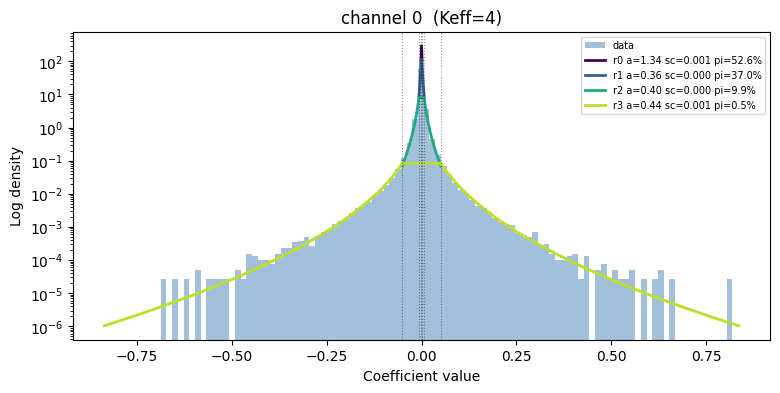

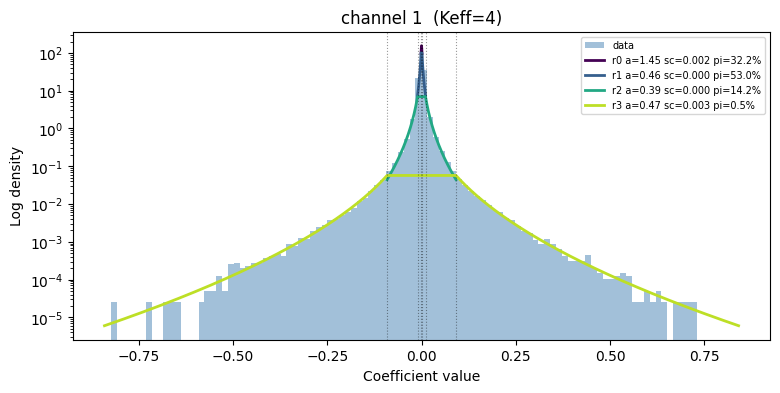

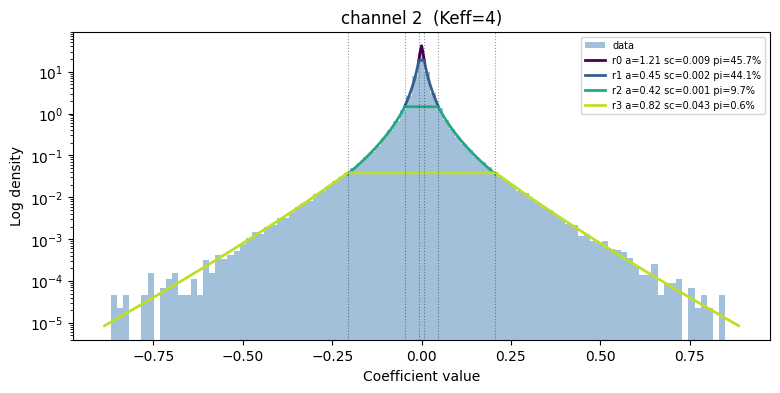

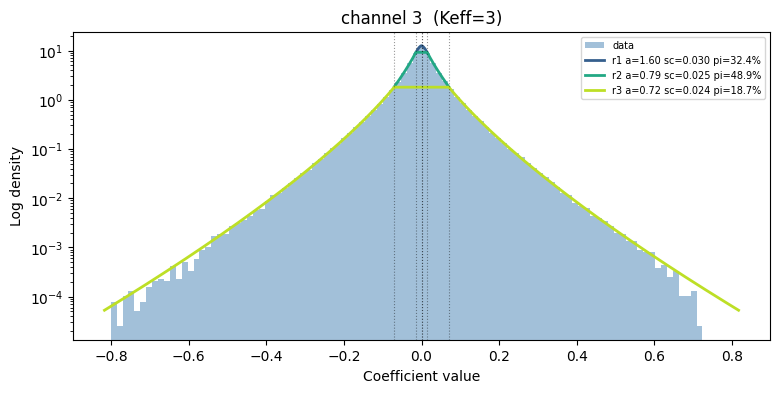

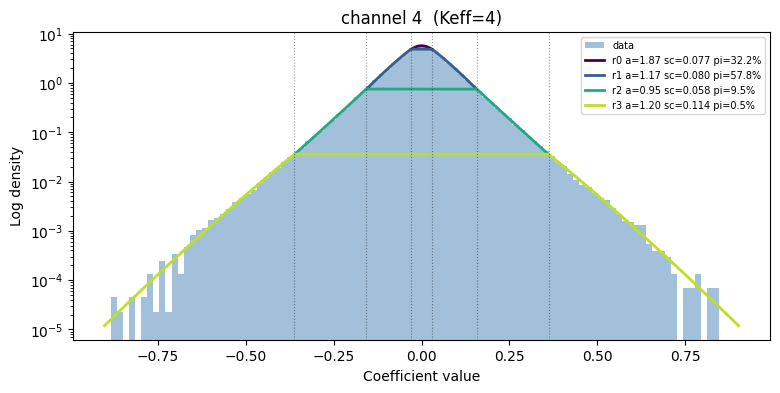

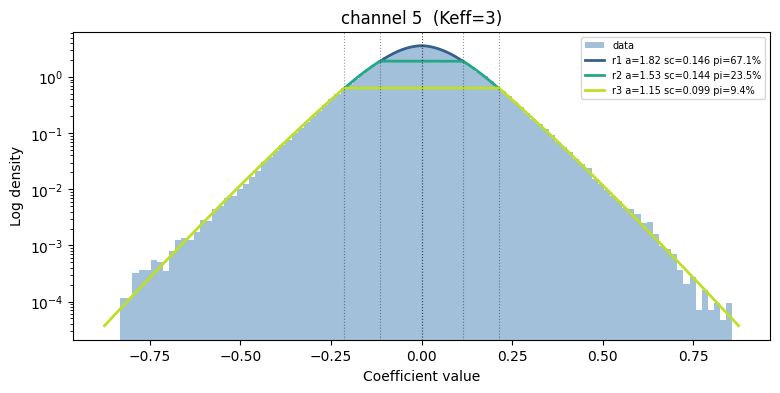

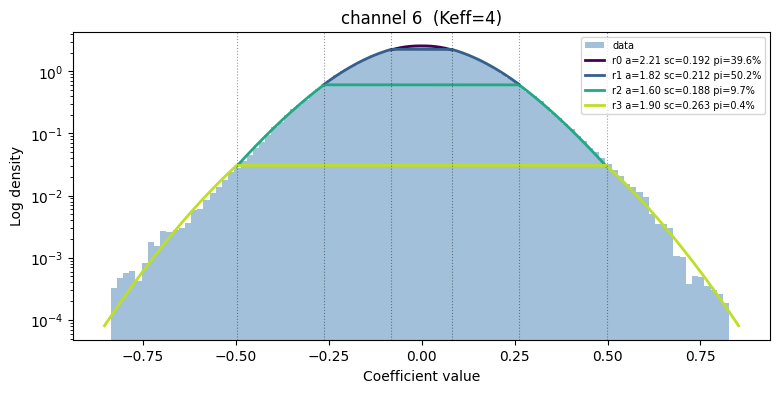

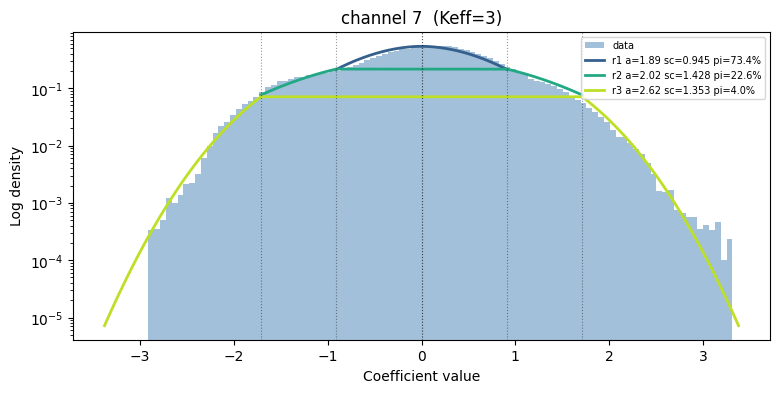

In [21]:
filters, filters_Phi = return_Filters(M, J, 1, device=device, include_phi=True)
model = Scalar_GGD_KRegion(filters)
model.fit_reference(x1)

/tmp/ipykernel_184459/1751255731.py:72: RuntimeWarning: overflow encountered in exp
  g = [1.0 / (1.0 + np.exp(-(C[j, m] - az) / SW[j, m]))


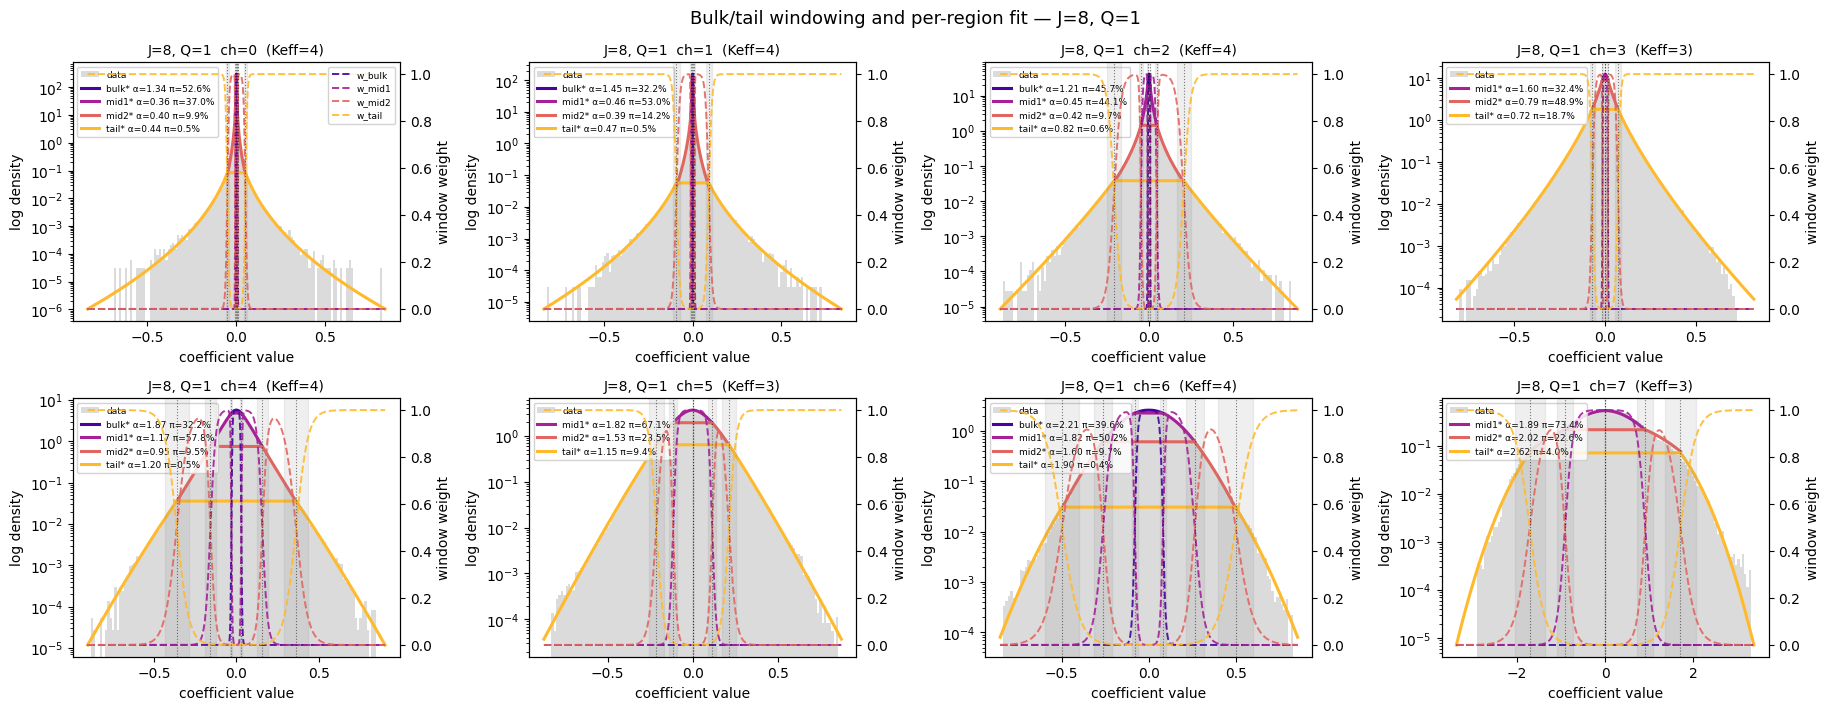

In [35]:
plot_kregion_fit_with_windows(x1, model, label="J=8, Q=1")

### choose the one for the paper 

/tmp/ipykernel_184459/1551578019.py:211: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


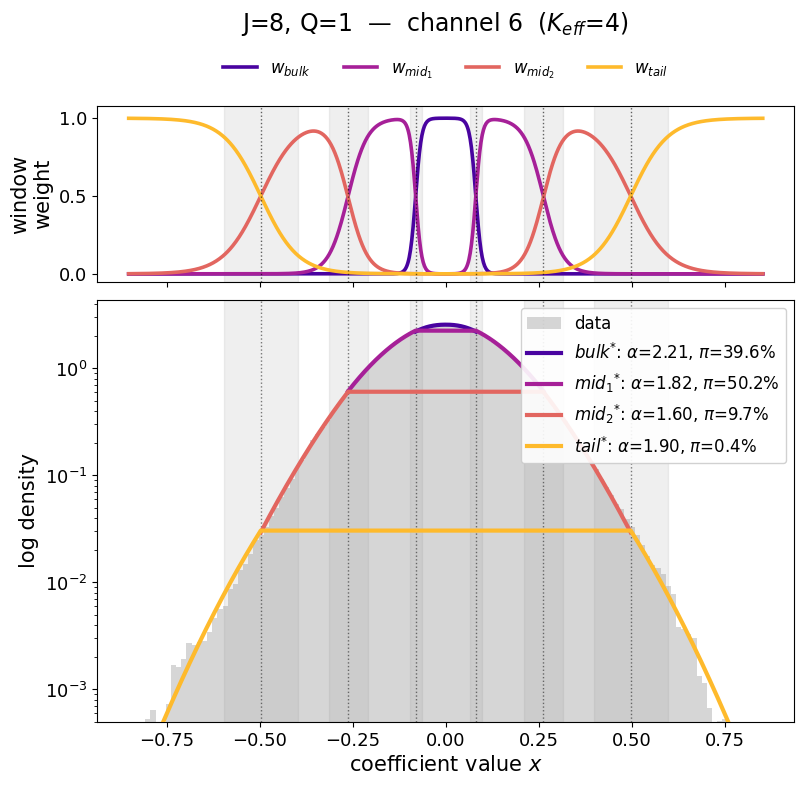

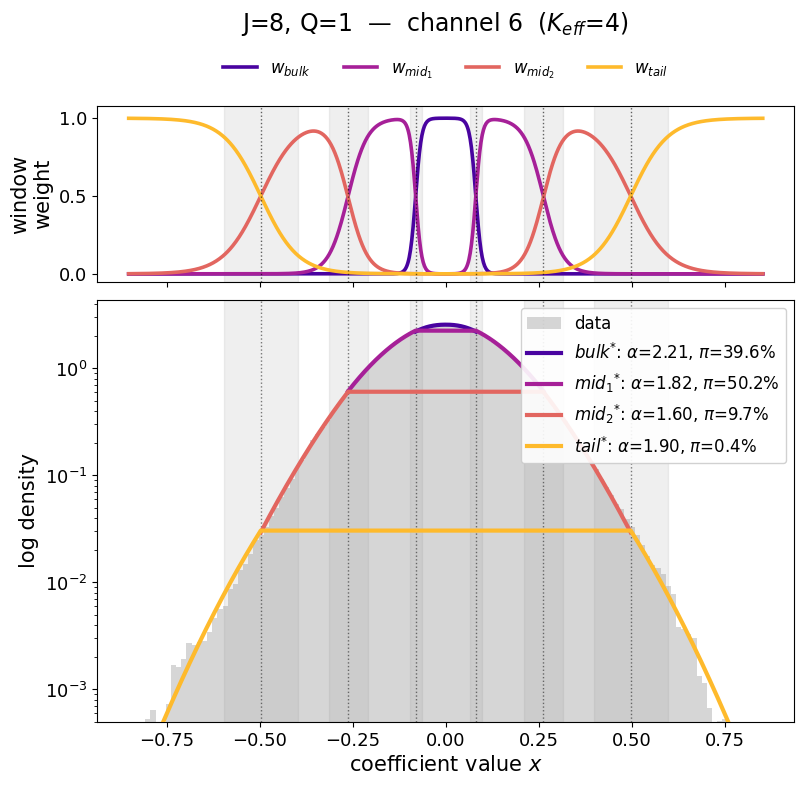

In [40]:
plot_kregion_fit_paper(x1, model, channel=6, label="J=8, Q=1")

### Q = 3

    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-32437430  K2=-32676197  K3=-32719321  K4=-32720509)
[GGD^4][ch 0] Keff=4  cuts=[0.0002 0.0007 0.0055]  pi=[52.9% 37.1% 9.5% 0.5%]  alpha=[1.85 0.69 0.41 0.41]  active=4
    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-33009899  K2=-33294852  K3=-33342555  K4=-33345310)
[GGD^4][ch 1] Keff=4  cuts=[0.0002 0.0007 0.0076]  pi=[53.0% 37.0% 9.5% 0.5%]  alpha=[1.79 0.53 0.38 0.41]  active=4
    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-30826687  K2=-31131823  K3=-31158416  K4=-31167112)
[GGD^4][ch 2] Keff=4  cuts=[0.0002 0.0008 0.0049]  pi=[59.6% 26.2% 11.8% 2.4%]  alpha=[1.62 0.38 0.38 0.39]  active=4
    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-28041241  K2=-28257325  K3=-28276897  K4=-28286900)
[GGD^4][ch 3] Keff=4  cuts=[0.0003 0.0013 0.0285]  pi=[52.8% 28.7% 18.0% 0.5%]  alpha=[1.55 0.35 0.36 0.42]  active=4
    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-24680341  K2=-24770988  K3=-24790649  K4=-24794415)
[GGD^4][ch 4] Keff=4

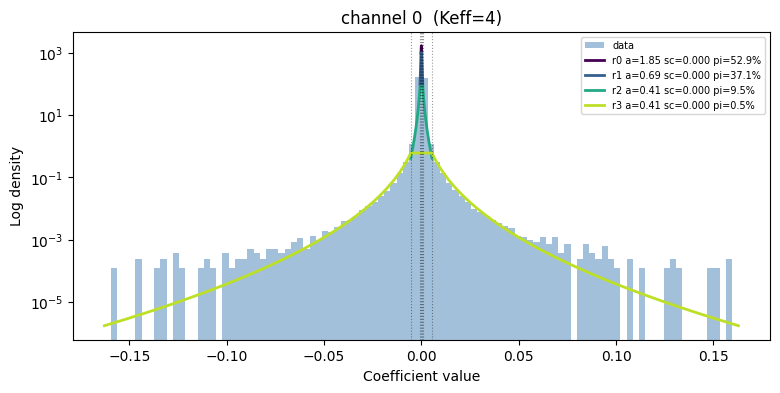

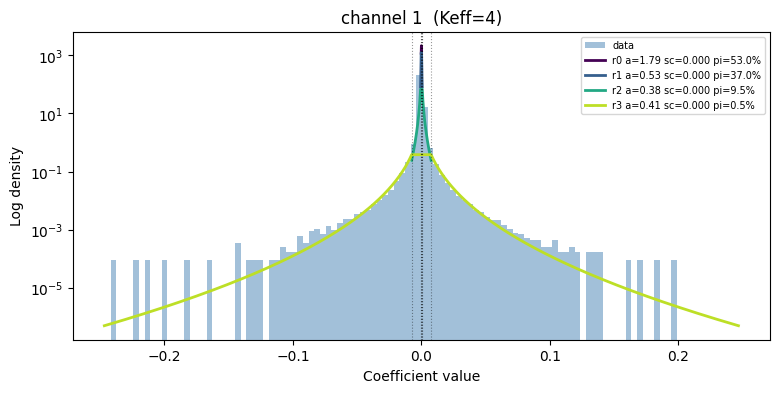

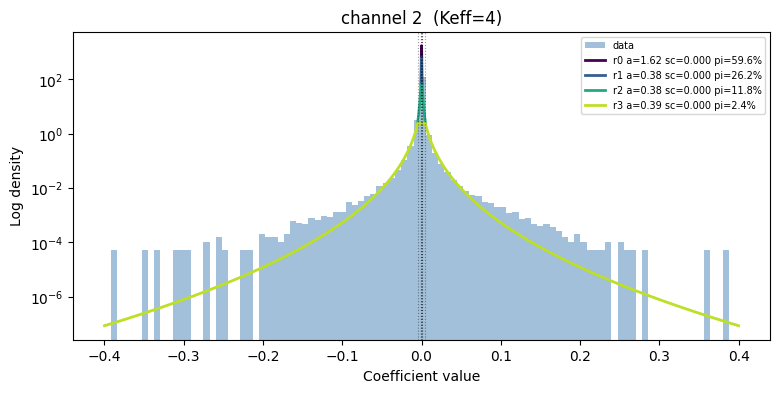

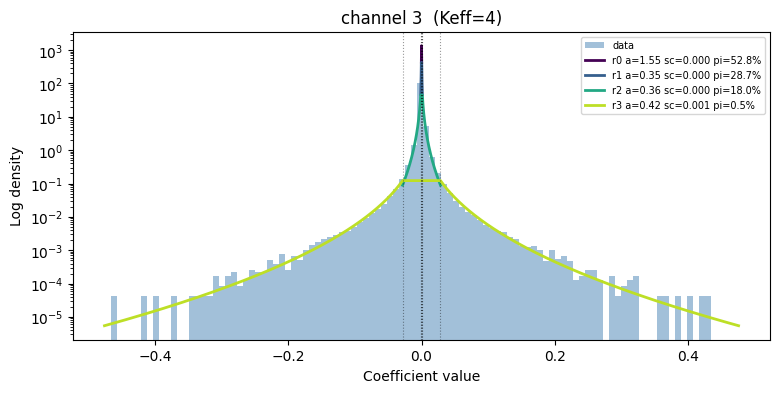

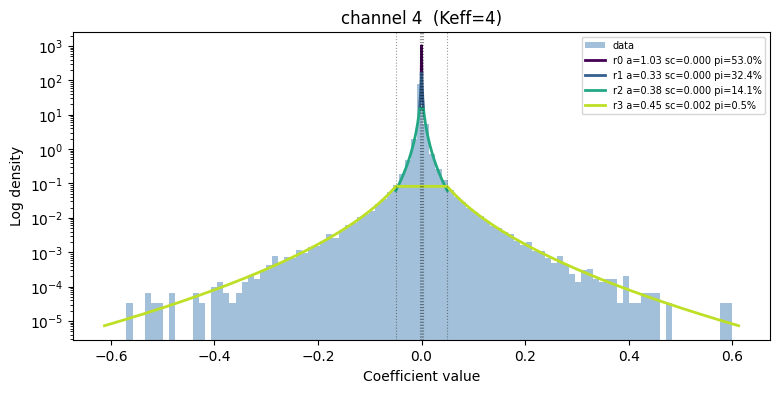

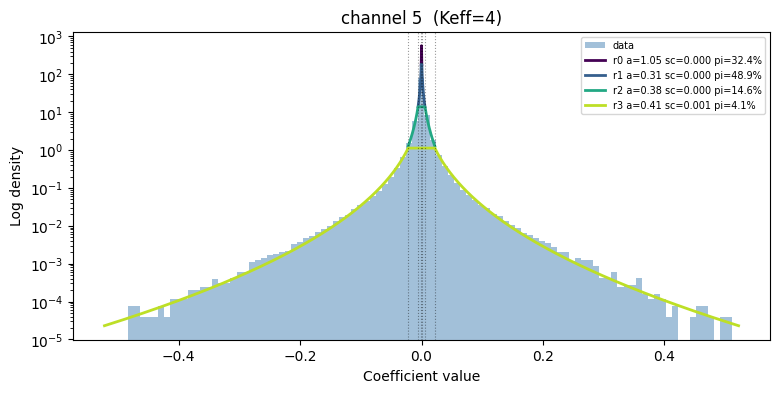

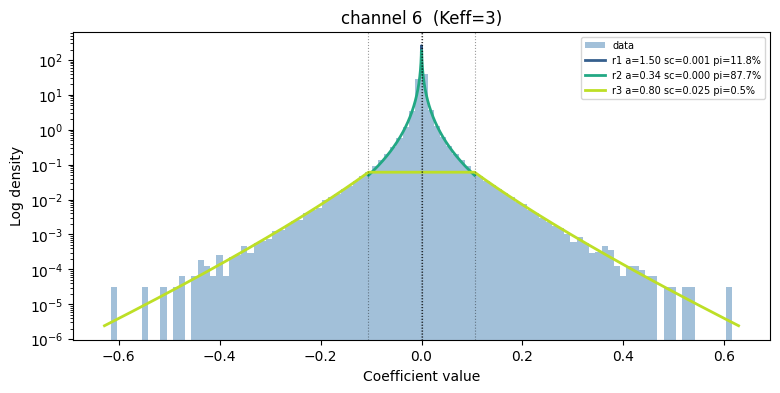

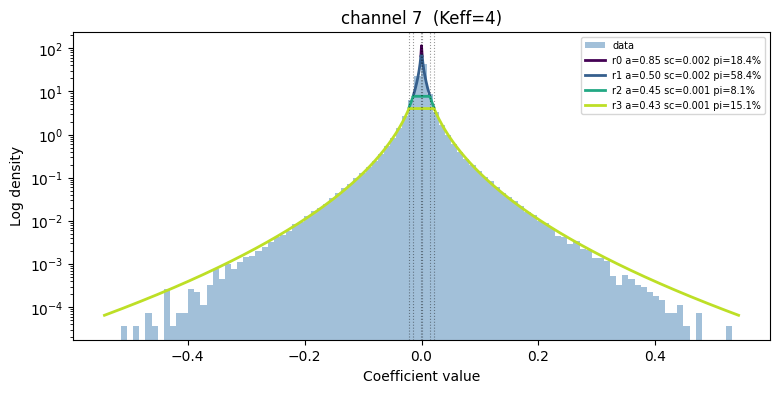

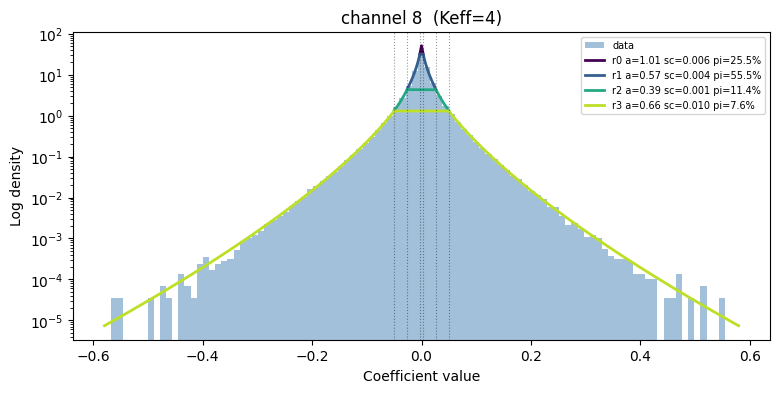

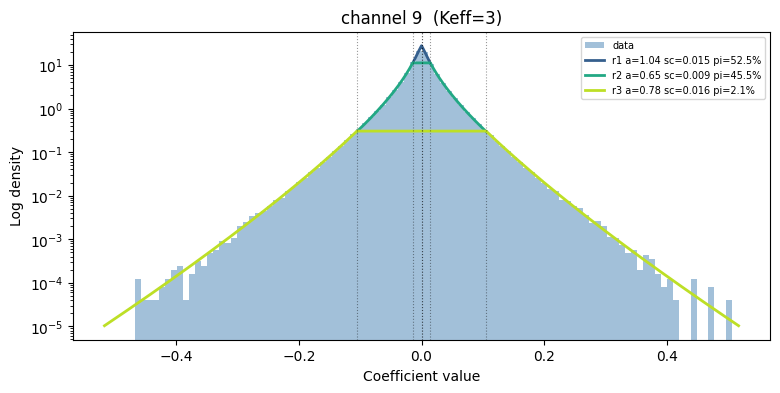

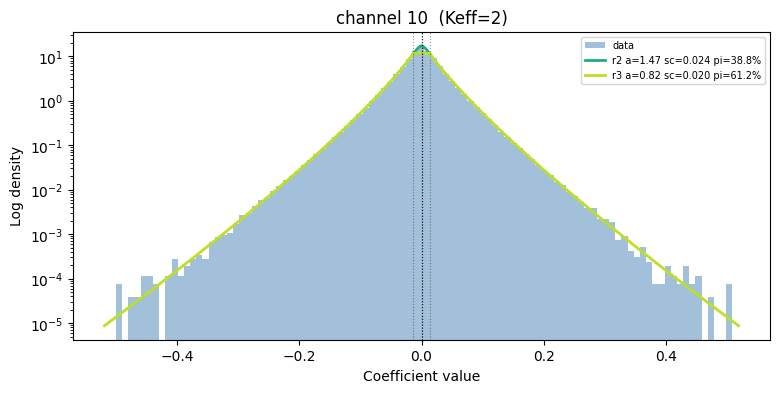

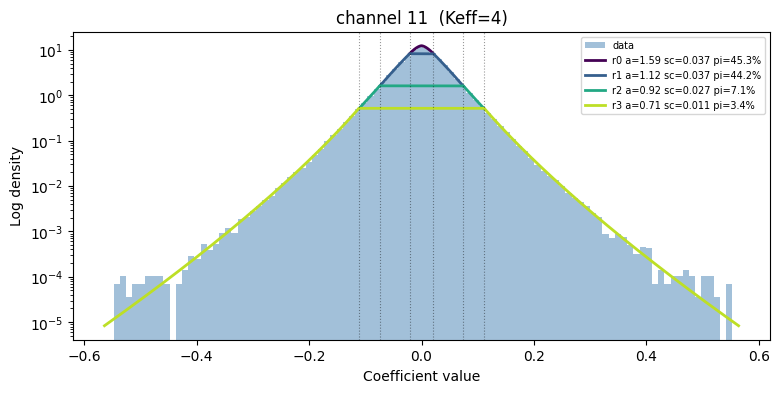

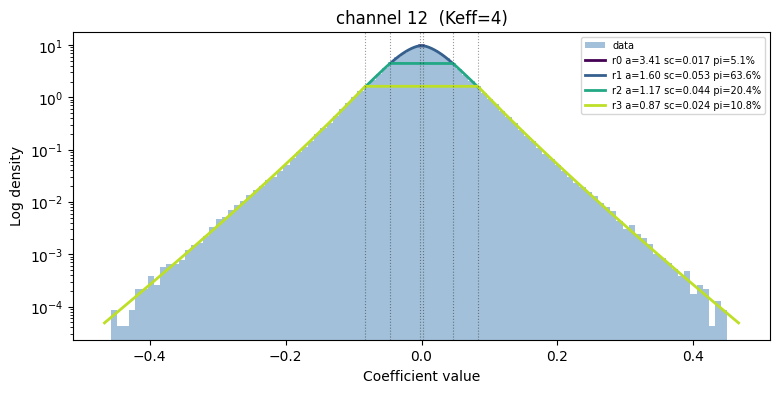

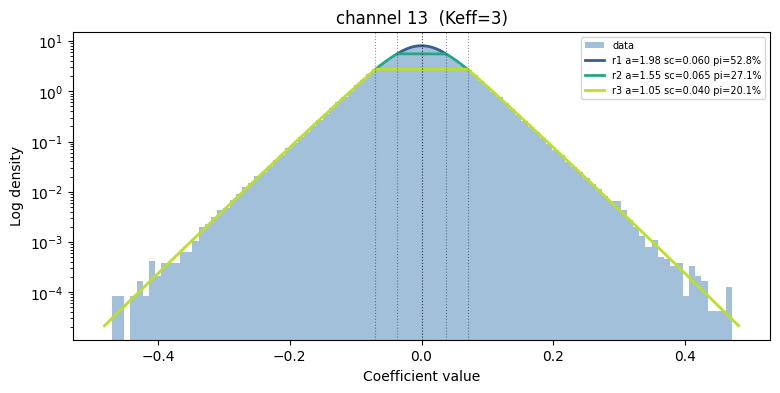

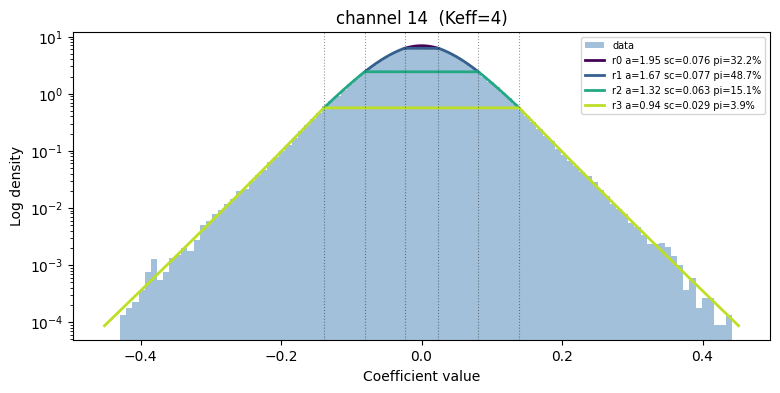

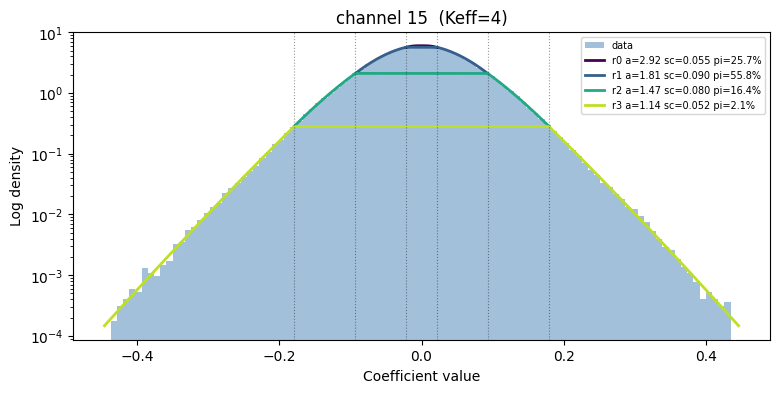

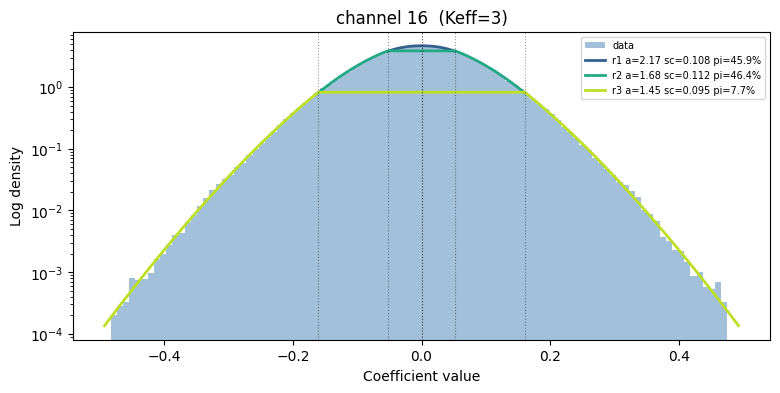

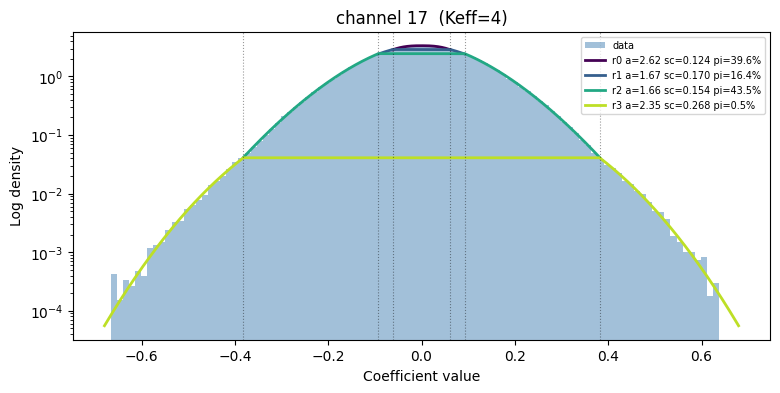

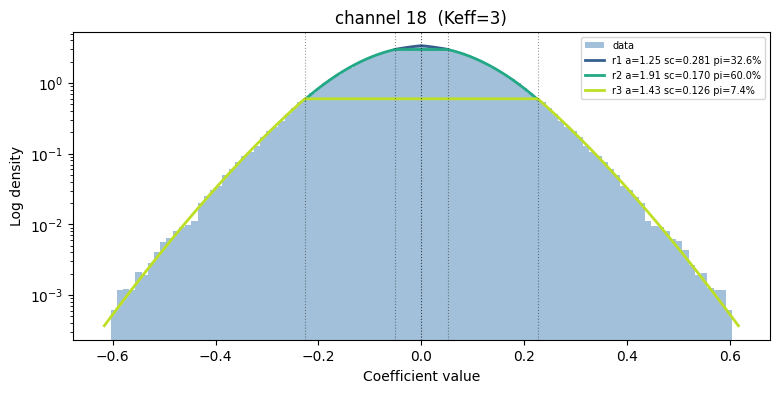

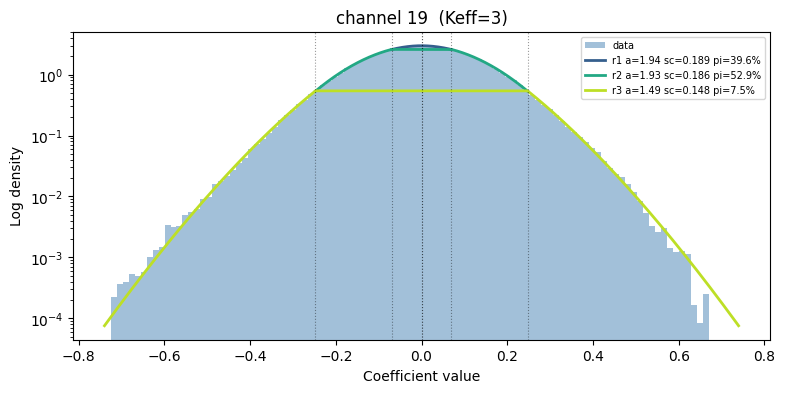

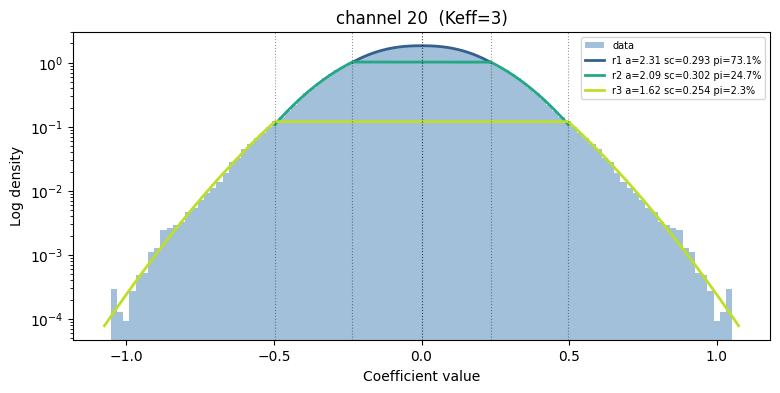

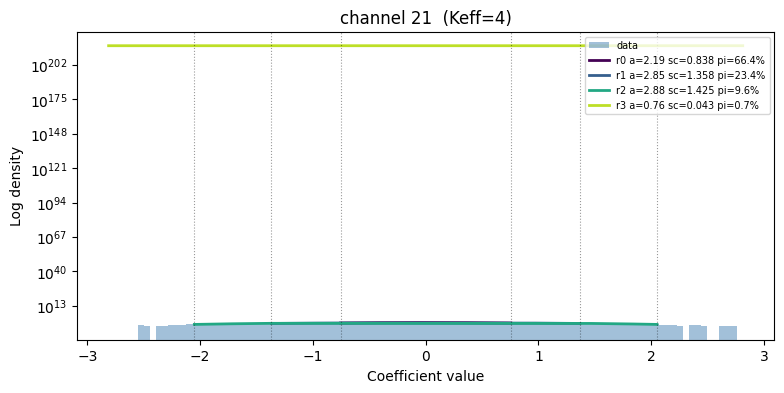

In [22]:
filtersQ3 = return_Filters(M, J, 3, device=device)
modelQ3 = Scalar_GGD_KRegion(filtersQ3)
modelQ3.fit_reference(x1)

/tmp/ipykernel_184459/2504940287.py:72: RuntimeWarning: overflow encountered in exp
  g = [1.0 / (1.0 + np.exp(-(C[j, m] - az) / SW[j, m]))


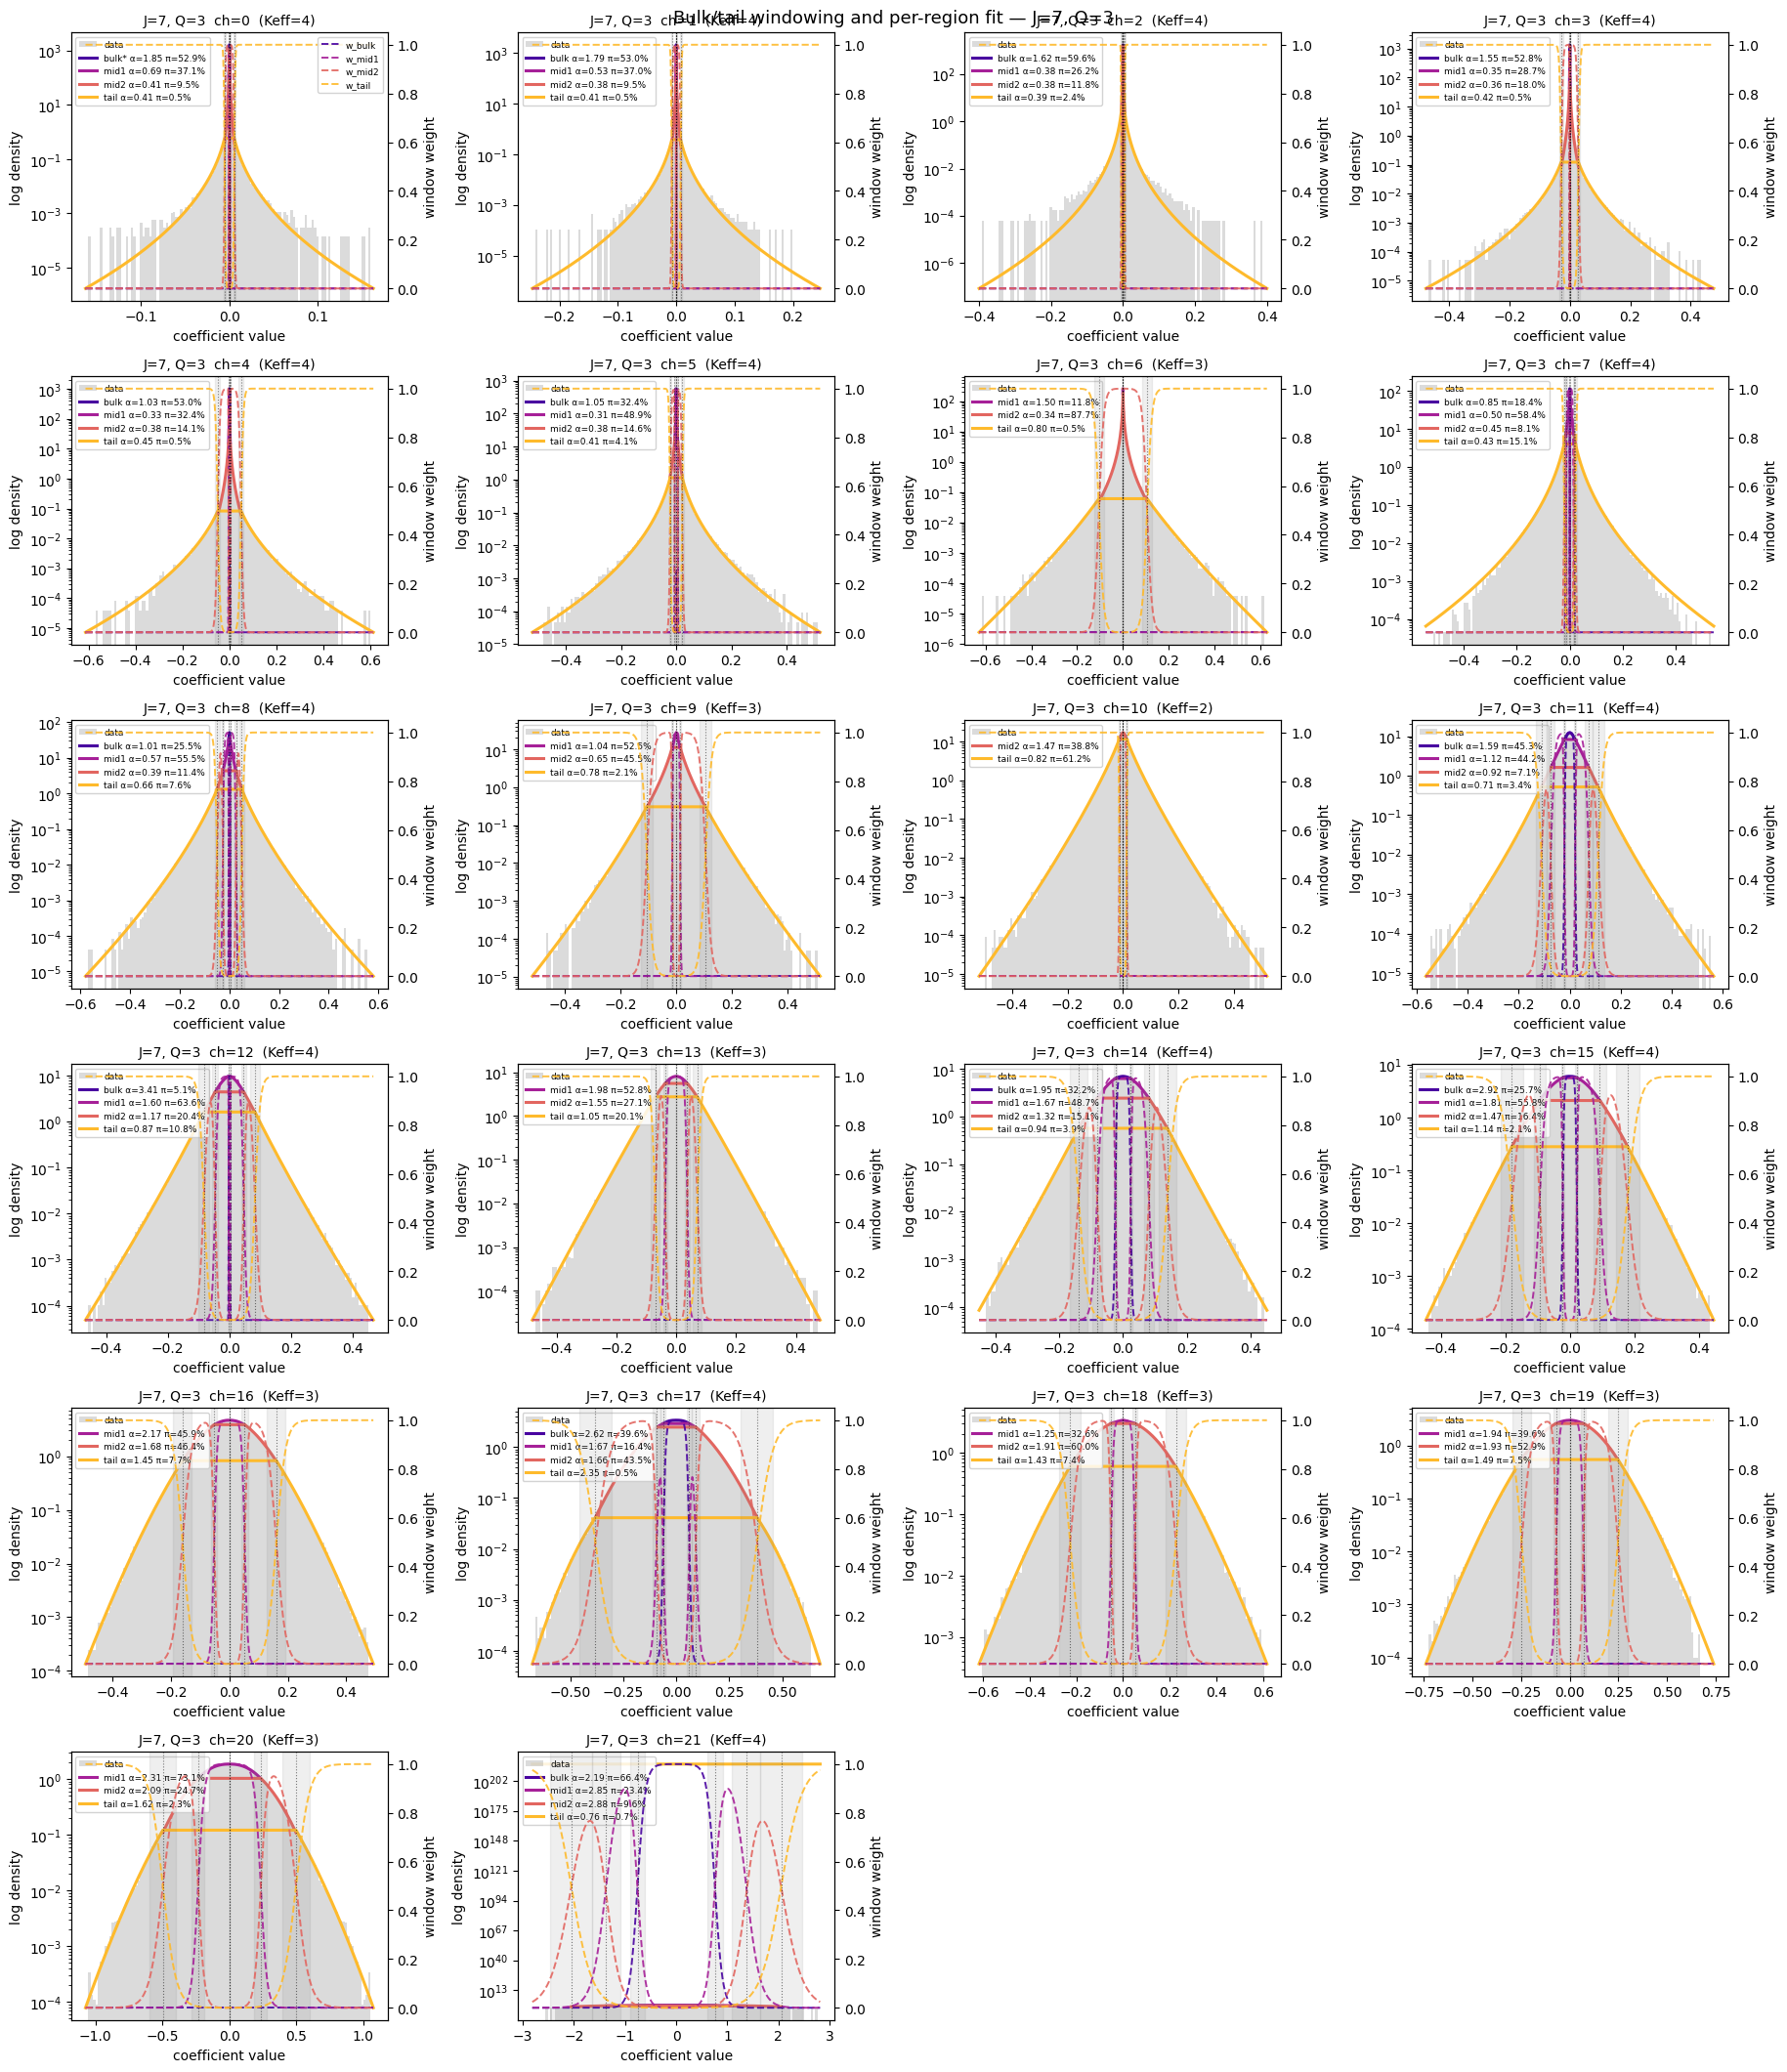

In [31]:
plot_kregion_fit_with_windows(x1, modelQ3, label="J=8, Q=3")

/tmp/ipykernel_184459/1768719295.py:156: RuntimeWarning: overflow encountered in exp
  g = [1.0 / (1.0 + np.exp(-(C[j, m] - az) / SW[j, m])) for m in range(K - 1)]
/tmp/ipykernel_184459/1768719295.py:211: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


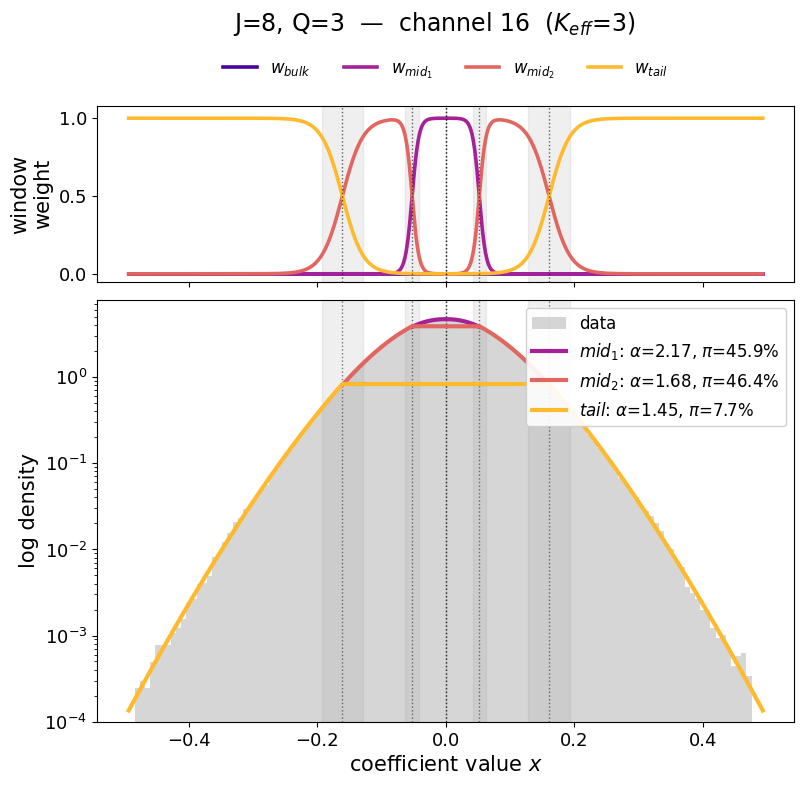

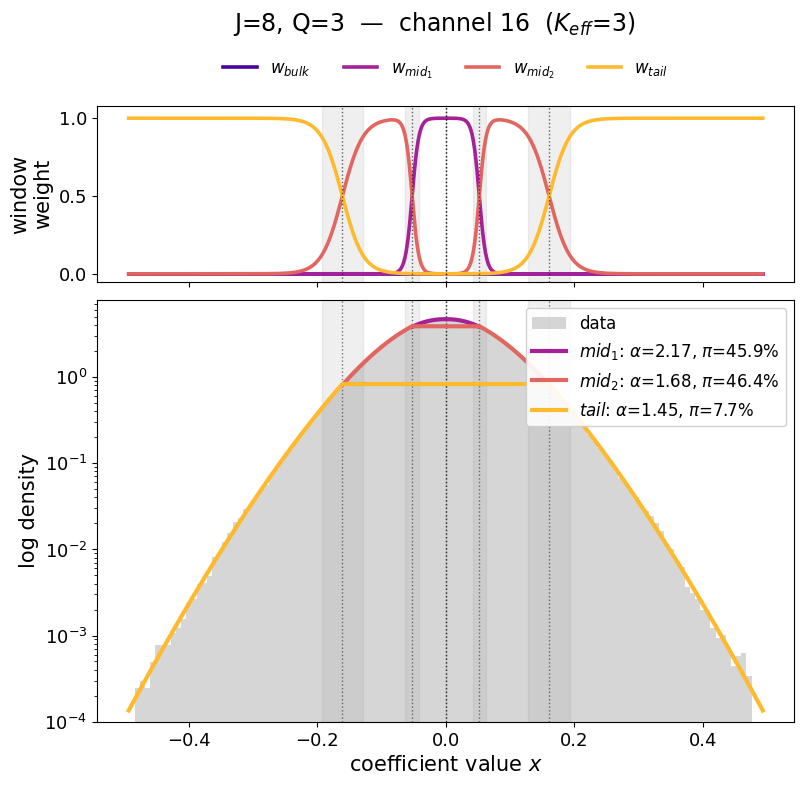

In [48]:
plot_kregion_fit_paper(x1, modelQ3, channel = 16, label="J=8, Q=3")

In [ ]:
x = normalize(Data[:10000]).to(device) # choose here if you want less data 
wt = torch.fft.ifft(torch.fft.fft(x) * filters).real  # (B, J, T)
n_wavelets = filters.shape[1]
# ------------------------------------------------------------------
# 1. Overview grid
# ------------------------------------------------------------------
ncols = 5
nrows = math.ceil(n_wavelets / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = axes.flatten()
for i in range(n_wavelets):
    vals = wt[:, i, :].detach().cpu().flatten().numpy()
    axes[i].hist(vals, bins=400, density=True, log=False)
    axes[i].set_xlabel("Coefficient value")
    axes[i].set_ylabel("Density")
for j in range(n_wavelets, len(axes)):
    axes[j].axis("off")
plt.suptitle(f"Wavelet coefficient histograms", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Q=1
filters = return_Filters(M, J, 1, device=device)
model = Scalar_coshgt(filters)
model.fit_reference(x1)        # or let fit_if_needed=True do it inside the plot call
plot_coshgt_wavelet_fit(x1, model, label="J=8,Q=1")

In [ ]:
# Q=3
filtersQ = return_Filters(M, J, Q, device=device)
modelQ3 = Scalar_coshgt(filtersQ)
modelQ3.fit_reference(x1)        # or let fit_if_needed=True do it inside the plot call
plot_coshgt_wavelet_fit(x1, modelQ3, label="J=8,Q=3")

## Fitting the imaginary part

In [ ]:
from scipy.special import betaln
from scipy.optimize import minimize

# ---------------------------------------------------------------------
# Generalized-t (McDonald–Newey): nests GGD (q→∞) and Student-t (p=2)
#   f(x) = p / [2 σ q^{1/p} B(1/p,q)] (1 + |x|^p/(q σ^p))^{-(q+1/p)}
# ---------------------------------------------------------------------
def gt_logpdf(x, p, q, sigma):
    z = np.abs(x) / sigma
    t = np.power(z, p) / q                      # |x|^p / (q σ^p)
    return (np.log(p) - np.log(2.0) - np.log(sigma)
            - np.log(q) / p - betaln(1.0 / p, q)
            - (q + 1.0 / p) * np.log1p(t))

def gt_pdf(x, p, q, sigma):
    return np.exp(gt_logpdf(x, p, q, sigma))

def gt_fit(h, p0=1.0, q0=5.0, sigma0=None):
    """MLE for symmetric GT (loc=0). Returns (p, q, sigma)."""
    if sigma0 is None:
        sigma0 = float(np.std(h)) or 1.0
    theta0 = np.log([p0, q0, sigma0])           # optimize in log-space (positivity)
    def nll(theta):
        p, q, sigma = np.exp(theta)
        return -gt_logpdf(h, p, q, sigma).sum()
    res = minimize(nll, theta0, method="L-BFGS-B")
    p, q, sigma = np.exp(res.x)
    return float(p), float(q), float(sigma)

from scipy.integrate import quad
from scipy.optimize import minimize

# f(x) ∝ (1 + (g_a(x)/x0)^b)^c,  g_a(x)=|x|cosh(ax),  c<0, b,x0>0, a>=0
#   a=0 → GT (power-law tail |x|^{bc});  a>0 → exp cutoff rate |c|·b·a
def _logcosh(z):
    z = np.abs(z)
    return z + np.log1p(np.exp(-2.0 * z)) - np.log(2.0)

def _logterm(x, a, b, x0):                       # b·log(g_a(x)/x0), stable
    lx = np.log(np.maximum(np.abs(x), 1e-300))
    return b * (lx + _logcosh(a * x) - np.log(x0))

def coshgt_logpdf_unnorm(x, a, b, c, x0):        # c·log(1+(g/x0)^b)
    return c * np.logaddexp(0.0, _logterm(x, a, b, x0))

def coshgt_logZ(a, b, c, x0):
    f = lambda t: np.exp(c * np.logaddexp(0.0, _logterm(t, a, b, x0)))
    I, _ = quad(f, 0.0, np.inf, limit=200)
    return np.log(2.0 * I)                        # symmetric → 2 × half-integral

def coshgt_pdf(x, a, b, c, x0):
    return np.exp(coshgt_logpdf_unnorm(x, a, b, c, x0) - coshgt_logZ(a, b, c, x0))

def coshgt_fit(h, a0=0.5, b0=1.0, c0=-2.0, x0_0=None, a_max=10.0):
    """MLE for (a, b, c, x0). a≈0 ⇒ power-law (GT) tail; a>0 ⇒ exp cutoff."""
    if x0_0 is None:
        x0_0 = float(np.std(h)) or 1.0
    theta0 = np.array([np.log(a0), np.log(b0), np.log(-c0), np.log(x0_0)])
    def unpack(th):
        a = min(np.exp(th[0]), a_max)
        return a, np.exp(th[1]), -np.exp(th[2]), np.exp(th[3])   # a>=0, b>0, c<0, x0>0
    def nll(th):
        a, b, c, x0 = unpack(th)
        ll = coshgt_logpdf_unnorm(h, a, b, c, x0) - coshgt_logZ(a, b, c, x0)
        return -np.sum(ll)
    res = minimize(nll, theta0, method="Nelder-Mead",
                   options=dict(xatol=1e-4, fatol=1e-4, maxiter=8000))
    return unpack(res.x)

#####################################################
# FITTING FUNCTION 
#####################################################
def plot_wavelet_fits(x: torch.Tensor, filters: torch.Tensor,
                      label: str = "Wavelet",
                     fit_coshgt: bool = True) -> None:
    """
    For a given filter bank, show:
      1. Grid of all wavelet coefficient histograms.
      2. Per-channel overlaid fits (GGD, Student-t and/or GT) on log-scale.
    Parameters
    ----------
    x : torch.Tensor, shape (B, C, T)
    filters : torch.Tensor, shape (1, J, T)  — Fourier-domain filter bank
    label : str
        Used in plot titles, e.g. "Q=1" or "Q=3".
    fit_student_t : bool
        Whether to fit and overlay a Student-t.
    fit_gennorm : bool
        Whether to fit and overlay a Generalized Gaussian.
    fit_gt : bool
        Whether to fit and overlay a generalized-t (nests GGD and Student-t).
    """
    wt = torch.fft.ifft(torch.fft.fft(x) * filters).imag  # (B, J, T)
    n_wavelets = filters.shape[1]
    # ------------------------------------------------------------------
    # 1. Overview grid
    # ------------------------------------------------------------------
    ncols = 5
    nrows = math.ceil(n_wavelets / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    axes = axes.flatten()
    for i in range(n_wavelets):
        vals = wt[:, i, :].detach().cpu().flatten().numpy()
        axes[i].hist(vals, bins=50, density=True, log=True)
        axes[i].set_title(f"{label}  ch={i}")
        axes[i].set_xlabel("Coefficient value")
        axes[i].set_ylabel("Density")
    for j in range(n_wavelets, len(axes)):
        axes[j].axis("off")
    plt.suptitle(f"Wavelet coefficient histograms  —  {label}", fontsize=13)
    plt.tight_layout()
    plt.show()
    # ------------------------------------------------------------------
    # 2. Per-channel fits
    # ------------------------------------------------------------------
    for i in range(n_wavelets):
        h = wt[:, i, :].detach().cpu().flatten().numpy()
        h = h[np.isfinite(h)]
        x_grid = np.linspace(h.min(), h.max(), 1000)
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.hist(h, bins=150, density=True, log=True,
                alpha=0.4, color="steelblue", label="data")
        legend_lines = []
        beta_hat = None
        nu_hat = None

        if fit_coshgt:
            try:
                a_, b_, c_, x0_ = coshgt_fit(h)
                pdf_cg = coshgt_pdf(x_grid, a_, b_, c_, x0_)
                l, = ax.plot(x_grid, pdf_cg, lw=2, color="darkred", linestyle=(0, (5, 1)),
                             label=rf"coshGT $a$={a_:.2f}, $b$={b_:.2f}, "
                                   rf"$c$={c_:.2f}, $x_0$={x0_:.3f}")
                legend_lines.append(l)
                print(f"[{label}  ch={i}]  coshGT: a={a_:.4f}, b={b_:.4f}, "
                      f"c={c_:.4f}, x0={x0_:.6f}  "
                      f"(power |bc|={abs(b_*c_):.2f}, exp rate |c|ba={abs(c_)*b_*a_:.3f})")
            except Exception as e:
                print(f"[{label}  ch={i}]  coshGT fit failed: {e}")

        ax.set_xlabel("Coefficient value")
        ax.set_ylabel("Log density")
        ax.set_title(f"{label}  —  channel {i}")
        ax.legend(frameon=False)
        plt.tight_layout()
        plt.show() 

## Compare real and imaginary part of wavelet coefficient plots 

In [ ]:
def plot_wavelet_real_imag(x1: torch.Tensor, filters: torch.Tensor,
                      label: str = "Wavelet",
                     fit_coshgt: bool = True) -> None:
    
    # 1. Ensure x1 has a singleton dimension for broadcasting over filters
    # If x1 is (B, T), unsqueeze(1) makes it (B, 1, T) so it broadcasts over (1, J, T) filters
    x1_fft = torch.fft.fft(x1.unsqueeze(1) if x1.ndim == 2 else x1)
    
    # 2. Perform the frequency-domain multiplication and IFFT
    wt_complex = torch.fft.ifft(x1_fft * filters)
    wt_imag = wt_complex.imag  # (B, J, T)
    wt_real = wt_complex.real  # (B, J, T)
    
    n_wavelets = filters.shape[1]
    
    # ------------------------------------------------------------------
    # 1. Overview grid
    # ------------------------------------------------------------------
    ncols = 5
    nrows = math.ceil(n_wavelets / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    
    # Handle edge case where n_wavelets = 1 (axes wouldn't be an array)
    if n_wavelets == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for i in range(n_wavelets):
        # .numpy() works smoothly if detached and moved to CPU
        vals_imag = wt_imag[:, i, :].detach().cpu().numpy().flatten()
        vals_real = wt_real[:, i, :].detach().cpu().numpy().flatten()
    
        axes[i].hist(vals_imag, bins=50, density=True, log=True, alpha=0.5, label="Imag")
        axes[i].hist(vals_real, bins=50, density=True, log=True, alpha=0.5, label="Real")
        axes[i].set_title(f"{label} ch={i}")
        axes[i].set_xlabel("Coefficient value")
        axes[i].set_ylabel("Density")
        if i == 0:
            axes[i].legend()  # Add a legend to the first plot for clarity
    
    # Hide unused subplots
    for j in range(n_wavelets, len(axes)):
        axes[j].axis("off")
    
    plt.suptitle(f"Wavelet coefficient histograms — {label}", fontsize=13)
    plt.tight_layout()
    
    # 3. If this code is inside a loop, use plt.draw() or plt.pause() instead, 
    # or clear the figure afterward so the next loop can plot.
    plt.show()

In [ ]:
filters = return_Filters(M, J, 1, device=device)
plot_wavelet_real_imag(x1, filters, label="Q=1") 
filters_Q = return_Filters(M, J, 3, device=device)
plot_wavelet_real_imag(x1, filters_Q, label="Q=3") 


In [ ]:
def plot_coshgt_windows(x, filters, label="", bulk_quantile=0.990,
                         trans_quantiles=(0.985, 0.995), eps_scale=1e-6,
                         ncols=5, bins=80):
    """
    Visualize the Scalar_coshgt bulk/tail partition-of-unity windowing,
    overlaid on each channel's wavelet-coefficient histogram.

    Per channel j, replicates fit_reference's border/width exactly:
        c_  = quantile(|z|, bulk_quantile)
        s_  = (quantile(|z|, q_hi) - quantile(|z|, q_lo)) / 4
        s_  = max(s_, 0.05*(c_+eps_scale), eps_scale)
        w_tail(z) = sigmoid((|z|-c_)/s_),  w_bulk = 1 - w_tail
    """
    with torch.no_grad():
        z = torch.fft.ifft(filters * torch.fft.fft(x)).real  # (B, J, T)
    J = z.shape[1]
    ncols = min(ncols, J)
    nrows = math.ceil(J / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows))
    axes = np.atleast_1d(axes).flatten()
    q_lo, q_hi = trans_quantiles

    for j in range(J):
        h = z[:, j, :].detach().cpu().flatten().numpy()
        h = h[np.isfinite(h)]
        ah = np.abs(h)

        # --- exact border/width computation from fit_reference ---
        c_ = float(np.quantile(ah, bulk_quantile))
        band = float(np.quantile(ah, q_hi) - np.quantile(ah, q_lo))
        s_ = band / 4.0
        s_ = max(s_, 0.05 * (c_ + eps_scale), eps_scale)
        qlo_val = float(np.quantile(ah, q_lo))
        qhi_val = float(np.quantile(ah, q_hi))

        ax = axes[j]
        ax.hist(h, bins=bins, density=True, log=True,
                 color="0.75", edgecolor="none", zorder=1)
        ax.set_title(f"{label} ch={j}  c={c_:.3g}  s={s_:.3g}", fontsize=10)
        ax.set_xlabel("z"); ax.set_ylabel("density (log)")

        # --- window curves on a twin axis, in [0, 1] ---
        zmax = max(ah.max(), c_ + 6 * s_)
        zg = np.linspace(-zmax, zmax, 1000)
        az = np.abs(zg)
        w_tail = 1.0 / (1.0 + np.exp(-(az - c_) / s_))
        w_bulk = 1.0 - w_tail

        axt = ax.twinx()
        axt.plot(zg, w_bulk, color="tab:blue", lw=1.8, label="w_bulk", zorder=3)
        axt.plot(zg, w_tail, color="tab:red",  lw=1.8, label="w_tail", zorder=3)
        axt.set_ylim(-0.05, 1.05); axt.set_ylabel("window weight")

        # --- markers: border c (dashed), quantile band edges q_lo/q_hi (dotted),
        #     shaded +/-2s effective transition zone around the border ---
        for sign in (-1, 1):
            axt.axvline(sign * c_, color="k", ls="--", lw=1, alpha=0.7, zorder=2)
            axt.axvline(sign * qlo_val, color="tab:green", ls=":", lw=1, alpha=0.6, zorder=2)
            axt.axvline(sign * qhi_val, color="tab:green", ls=":", lw=1, alpha=0.6, zorder=2)
            axt.axvspan(sign * c_ - 2 * s_, sign * c_ + 2 * s_,
                        color="gray", alpha=0.15, zorder=0)

        if j == 0:
            axt.legend(loc="upper center", fontsize=8, framealpha=0.8)

    for k in range(J, len(axes)):
        axes[k].axis("off")

    plt.suptitle(f"coshGT bulk/tail windowing — {label}  "
                 f"(bulk_quantile={bulk_quantile}, trans_quantiles={trans_quantiles})",
                 fontsize=13)
    plt.tight_layout()
    plt.show()


filters = return_Filters(M, J, 1, device=device)
plot_coshgt_windows(x1, filters, label="Q=1")

filters_Q = return_Filters(M, J, 3, device=device)
plot_coshgt_windows(x1, filters_Q, label="Q=3")